# Examine version 3 of the catalog with amplitudes 

This notebook is used to check whether the amplitude information is correctly added to version 3 of the pick assignment table. 

By Hiroto Bito

In [1]:
import os
import sys
import pandas as pd
import numpy as np

from obspy.core import UTCDateTime
import time
from obspy.core.stream import Stream
import matplotlib.pyplot as plt
from tqdm import tqdm


parent_dir = '/home/hbito/cascadia_obs_ensemble/utils'
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from data_client import get_waveforms

In [2]:
datasets_dir =  '/wd1/hbito_data/data/datasets_all_regions'
path_assigned_picks_df = f'{datasets_dir}/Cascadia_updated_catalog_picks_assignment_ver_3_w_amp.csv'
assigned_picks_df = pd.read_csv(path_assigned_picks_df, index_col=False)

In [3]:
skipped_csv_path = f'{datasets_dir}/calculate_amplitudes_skipped_picks.csv'
skipped_picks_df = pd.read_csv(skipped_csv_path)

In [4]:
dir_plots = datasets_dir+'/plot_examine_amp_calculation'
os.makedirs(name=dir_plots, exist_ok=True)

In [5]:
# Print the number of rows of assigned_picks_df and the first 10 rows
print("Number of rows: ", len(assigned_picks_df))
assigned_picks_df.head(10)

Number of rows:  1004335


,Unnamed: 0,time_pick,station,phase,timeres,idx,arid,latitude,longitude,depth,Detection Value,time,RMS Residual (s),Num. P,Num. S,picks,slatitude,slongitude,selevation,Amplitude
0,0,2010-01-01T00:15:27.180000Z,UW.PCMD,P,0.049,0,0,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,46.888962,-122.301483,239.0,528.446789
1,1,2010-01-01T00:15:37.840400Z,UW.RVW,P,1.264,0,1,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,46.149750,-122.742996,504.0,73.754697
2,2,2010-01-01T00:15:33.280000Z,UW.PCMD,S,-0.243,0,2,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,46.888962,-122.301483,239.0,897.628533
3,3,2010-01-01T00:15:42.002000Z,UW.GNW,S,2.402,0,3,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,47.564130,-122.824980,220.0,1671.719173
4,4,2010-01-01T00:15:43.618400Z,PB.B013,S,-0.651,0,4,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,47.813000,-122.910797,75.3,60.723817
5,5,2010-01-01T00:15:43.768400Z,PB.B943,S,-0.511,0,5,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,47.813202,-122.911301,84.2,51.631734
6,6,2010-01-01T00:15:48.060400Z,UW.BOW,S,-0.263,0,6,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,46.474831,-123.229301,870.0,26.402961
7,7,2010-01-01T00:17:04.730000Z,UW.PASS,P,-0.499,1,7,48.17742,-121.83289,6.163,0.84,2010-01-01 00:16:49.343000+00:00,0.985,25,30,55,48.998299,-122.085197,175.4,246.836474
8,8,2010-01-01T00:17:05.008400Z,PB.B943,P,-0.252,1,8,48.17742,-121.83289,6.163,0.84,2010-01-01 00:16:49.343000+00:00,0.985,25,30,55,47.813202,-122.911301,84.2,45.998054
9,9,2010-01-01T00:17:05.020400Z,UW.BLN,P,0.415,1,9,48.17742,-121.83289,6.163,0.84,2010-01-01 00:16:49.343000+00:00,0.985,25,30,55,48.006624,-122.972646,601.0,94.531225


In [6]:
# Print the number of rows of assigned_picks_df and the first 10 rows
print("Number of rows: ", len(skipped_picks_df))
skipped_picks_df.head(10)

Number of rows:  49290


,network,station,channel,origin_time,time_pick,starttime,endtime,reason
0,UW,SP2,*H*,2010-04-30T16:01:16.639000Z,2010-04-30T16:01:35.360000Z,2010-04-30T16:01:05.360000Z,2010-04-30T16:04:05.360000Z,Request failed: No Vertical Component Data Pre...
1,UW,SP2,*H*,2010-05-01T04:18:47.446000Z,2010-05-01T04:18:57.850000Z,2010-05-01T04:18:27.850000Z,2010-05-01T04:21:27.850000Z,Request failed: No Vertical Component Data Pre...
2,UW,SP2,*H*,2010-06-22T15:49:24.169000Z,2010-06-22T15:49:37.870000Z,2010-06-22T15:49:07.870000Z,2010-06-22T15:52:07.870000Z,Request failed: No Vertical Component Data Pre...
3,UW,SP2,*H*,2010-07-31T04:04:17.592000Z,2010-07-31T04:05:02.760000Z,2010-07-31T04:04:32.760000Z,2010-07-31T04:07:32.760000Z,Request failed: No Vertical Component Data Pre...
4,UW,SP2,*H*,2010-08-09T03:50:22.194000Z,2010-08-09T03:50:52.920000Z,2010-08-09T03:50:22.920000Z,2010-08-09T03:53:22.920000Z,Request failed: No Vertical Component Data Pre...
5,UW,SP2,*H*,2010-08-11T13:06:01.021000Z,2010-08-11T13:06:19.890000Z,2010-08-11T13:05:49.890000Z,2010-08-11T13:08:49.890000Z,Request failed: No Vertical Component Data Pre...
6,BK,JCC,*H*,2011-01-06T04:29:53.238000Z,2011-01-06T04:30:04.558391Z,2011-01-06T04:29:34.558391Z,2011-01-06T04:32:34.558391Z,Request failed: No Vertical Component Data Pre...
7,BK,JCC,*H*,2011-01-06T05:52:43.509000Z,2011-01-06T05:52:50.528391Z,2011-01-06T05:52:20.528391Z,2011-01-06T05:55:20.528391Z,Request failed: No Vertical Component Data Pre...
8,BK,JCC,*H*,2011-01-06T06:27:55.741000Z,2011-01-06T06:28:02.078391Z,2011-01-06T06:27:32.078391Z,2011-01-06T06:30:32.078391Z,Request failed: No Vertical Component Data Pre...
9,BK,JCC,*H*,2011-01-06T08:14:36.764000Z,2011-01-06T08:14:46.728391Z,2011-01-06T08:14:16.728391Z,2011-01-06T08:17:16.728391Z,Request failed: No Vertical Component Data Pre...


### Make plots to make sure that the amplitude calculation was correct

test

In [ ]:
# assigned_picks_df.iloc[0]['time_pick']

'2010-01-01T00:15:27.180000Z'

In [ ]:
# # Define the arguments 
# row = assigned_picks_df.iloc[0]
# window_before = 0.5
# window_after = 2

# date, _time = row['time'].split(' ')
# datetime_str = date+'T'+_time
# origin_time = UTCDateTime(datetime_str)  # Accept ISO string directly

# time_pick_str = row['time_pick'] 
# time_pick = UTCDateTime(time_pick_str)  # Accept ISO string directly

# network = row['station'].split('.')[0].strip()
# station = row['station'].split('.')[1].strip()
# channel = '*H*'
# starttime = time_pick - window_before 
# endtime = time_pick + window_after

# source = 'pnwstore'
 

# # Request a waveform
# time.sleep(0.1)

# # Request a waveform
# time.sleep(0.1)

# try:
#     st = get_waveforms(network=network, station=station, channel=channel,
#                         starttime=starttime, endtime=endtime,
#                         source=source)
# except Exception as e:
#     print(f"Request failed: {e}")

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


endtest

In [12]:
# Function to plot waveforms using Obspy bulk request
def plot_waveforms_for_picks(assigned_picks_df, dir_plots, ls_idx, window_before=30, window_after=120, window_amp_calc_before=0.5, window_amp_calc_after=2, source='pnwstore', scaling_factor_vline=0.1):

    # Prepare the lists
    bulk = []
    pick_info = []
    # ls_idx = np.arange(n_picks)
    
    # for i, row in assigned_picks_df.head(n_picks).iterrows():
    for i in range(len(ls_idx)):
        orid = assigned_picks_df.iloc[ls_idx[i]]['idx']
        pick_id = assigned_picks_df.iloc[ls_idx[i]]['arid']
      
        date, _time = assigned_picks_df.iloc[ls_idx[i]]['time'].split(' ')
        datetime_str = date+'T'+_time
        origin_time = UTCDateTime(datetime_str)  # Accept ISO string directly
        latitude = assigned_picks_df.iloc[ls_idx[i]]['latitude']
        longitude = assigned_picks_df.iloc[ls_idx[i]]['longitude']
        depth = assigned_picks_df.iloc[ls_idx[i]]['depth']
        
        # You may need to adjust these fields to match your DataFrame columns
        network = assigned_picks_df.iloc[ls_idx[i]]['station'].split('.')[0].strip()
        station = assigned_picks_df.iloc[ls_idx[i]]['station'].split('.')[1].strip()
        channel = "*H*"
        time_pick = UTCDateTime(assigned_picks_df.iloc[ls_idx[i]]['time_pick'])
        time_pick_origin  = UTCDateTime(assigned_picks_df.iloc[ls_idx[i]]['time_pick']) - origin_time
        starttime = time_pick - window_before 
        endtime = time_pick + window_after
        phase = assigned_picks_df.iloc[ls_idx[i]]['phase']
        amp = assigned_picks_df.iloc[ls_idx[i]]['Amplitude']

        bulk.append((network, station, channel, starttime, endtime))
        pick_info.append({
            'orid': orid,
            'pick_id': pick_id,
            'origin_time': origin_time,
            'latitude': latitude,
            'longitude': longitude,
            'depth': depth,
            'network': network,
            'station': station,
            'channel': channel,
            'starttime': starttime,
            'endtime': endtime,
            'time_pick': time_pick,
            'time_pick_origin': time_pick_origin,
            'phase': phase,
            'amp': amp
        })


    # Parameters to process waveforms
    new_sampling_rate = 100 # in Hz
    # freqmax = 15 # in Hz
    # freqmin = 4 # in Hz
    freq_highpass = 2 # in Hz


    # Plotting
    for i, info in enumerate(pick_info):

        network = pick_info[i]['network']
        station = pick_info[i]['station']
        channel = pick_info[i]['channel']
        starttime = pick_info[i]['starttime']
        endtime = pick_info[i]['endtime']
        amp = pick_info[i]['amp']

        time_pick = pick_info[i]['time_pick']
        time_pick_origin = pick_info[i]['time_pick_origin']

        fname = dir_plots+f"/{network}_{station}_arid_{info['pick_id']}.png"

        time.sleep(0.1)

        try:
            st = get_waveforms(
                network=network,
                station=station,
                channel=channel,
                starttime=starttime,
                endtime=endtime,
                source=source
            )
        except Exception as e:
            print(f"Request failed: {e}")
            st = Stream()

        time.sleep(0.1)

        # ---------------------------------------------------------
        # Select preferred channel family
        # ---------------------------------------------------------

        has_HH = bool(st.select(id=f'{network}.{station}..HH?'))
        has_BH = bool(st.select(id=f'{network}.{station}..BH?'))
        has_EH = bool(st.select(id=f'{network}.{station}..EH?'))

        sdata = Stream()

        if has_HH:
            sdata += st.select(id=f'{network}.{station}..HH*')
            channel_prefix = "HH"

        elif has_BH:
            sdata += st.select(id=f'{network}.{station}..BH*')
            channel_prefix = "BH"

        elif has_EH:
            sdata += st.select(id=f'{network}.{station}..EH*')
            channel_prefix = "EH"

        else:
            print(f'No HH, BH, or EH data available at {network}.{station} at {time_pick}. Skipping.')
            continue

        #---Debug---#

        sdata.resample(new_sampling_rate)

        sdata.detrend(type='demean')
        sdata.taper(max_percentage=0.05)
        sdata.filter(type='highpass', freq=freq_highpass)

        max_amp = 0
        for tr in sdata:
            print('First print of max_amp',max_amp)
            print('np.max(np.absolute(tr.data))',np.max(np.absolute(tr.data)))
            
            max_amp = max(max_amp, np.absolute(tr.data).max())
            
            print('Second print of max_amp',max_amp)

        #---End debug---#

        # ---------------------------------------------------------
        # Create figure with 3 components
        # ---------------------------------------------------------

        fig, axes = plt.subplots(
            3,
            1,
            figsize=(12, 8),
            sharex=True
        )

        component_list = ['Z', '[N2]', '[E1]']

        for ax, comp in zip(axes, component_list):

            tr_select = sdata.select(channel=f"{channel_prefix}{comp}")

            # -----------------------------------------------------
            # Leave blank if component does not exist
            # -----------------------------------------------------

            if len(tr_select) == 0:

                ax.set_title(f"{channel_prefix}{comp} : No Data")
                ax.grid()

                continue

            tr = tr_select[0].copy()

            # -----------------------------------------------------
            # Process waveform
            # -----------------------------------------------------

            data = tr.data

            times = np.linspace(
                -window_before,
                window_after,
                tr.stats.npts
            )

            # print('times', times)
            time_vline = 0

            ymax = np.max(np.abs(data)) * scaling_factor_vline
            ymin = -np.max(np.abs(data)) * scaling_factor_vline

            xmax = time_vline + window_amp_calc_after
            xmin = time_vline - window_amp_calc_before

            # -----------------------------------------------------
            # Plot waveform
            # -----------------------------------------------------

            ax.axvspan(
                xmin,
                xmax,
                color='b',
                alpha=0.2
            )

            ax.plot(times, data)

            ax.vlines(
                time_vline,
                ymin,
                ymax,
                color='k',
                linestyles='solid'
            )

            ax.hlines(
                amp,
                xmax=xmax,
                xmin=xmin,
                color='r'
            )

            ax.hlines(
                -amp,
                xmax=xmax,
                xmin=xmin,
                color='r'
            )

            ax.set_ylabel(comp)
            ax.grid()

        # ---------------------------------------------------------
        # Common formatting
        # ---------------------------------------------------------

        axes[0].set_title(
            f"Origin ID: {info['orid']} | "
            f"Pick ID: {info['pick_id']} | "
            f"Network: {info['network']} | "
            f"Station: {info['station']} | "
            f"Channel: {channel_prefix} | "
            f"Phase: {info['phase']}"
        )

        axes[-1].set_xlabel("Time (s) from Origin Time")

        ticks = np.arange(-window_before, window_after, 10)
        str_ticks = [str(t) for t in ticks]

        axes[-1].set_xticks(ticks=ticks, labels=str_ticks)

        # Event information box
        info_text = (
            f"Origin Time: {info['origin_time']}\n"
            f"Latitude: {info['latitude']}\n"
            f"Longitude: {info['longitude']}\n"
            f"Depth: {info['depth']}\n"
            f"Amplitude: {np.round(amp, decimals=1)}"
        )

        props = dict(
            boxstyle='round',
            facecolor='wheat',
            alpha=0.5
        )

        axes[0].text(
            0.98,
            0.98,
            info_text,
            transform=axes[0].transAxes,
            fontsize=10,
            verticalalignment='top',
            horizontalalignment='right',
            bbox=props
        )

        plt.tight_layout()
        plt.show()
        plt.savefig(fname=fname, format='png')
        plt.close(fig)

        time.sleep(0.1)



In [13]:
# Define the variables in the function
n_picks = 20
ls_arid = np.random.choice(a=len(assigned_picks_df), size=(n_picks))
window_before = 30 # in sec
window_after = 150 # in sec
window_amp_calc_before=0.5 # in sec
window_amp_calc_after=2 # in sec
source = 'pnwstore'
scaling_factor_vline = 0.3

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


First print of max_amp 0
np.max(np.absolute(tr.data)) 290.81165723164236
Second print of max_amp 290.81165723164236
First print of max_amp 290.81165723164236
np.max(np.absolute(tr.data)) 652.6845118230949
Second print of max_amp 652.6845118230949
First print of max_amp 652.6845118230949
np.max(np.absolute(tr.data)) 502.87147204324253
Second print of max_amp 652.6845118230949


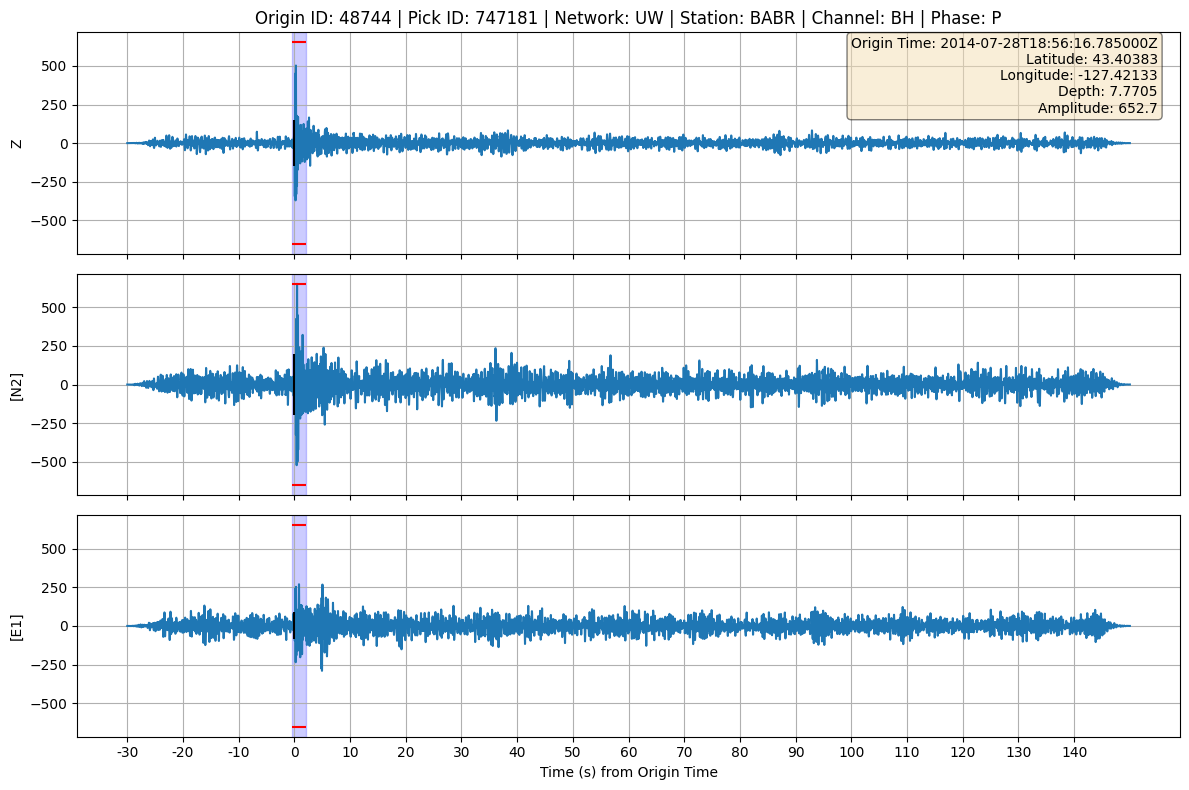

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


First print of max_amp 0
np.max(np.absolute(tr.data)) 87.17484351487983
Second print of max_amp 87.17484351487983


<Figure size 640x480 with 0 Axes>

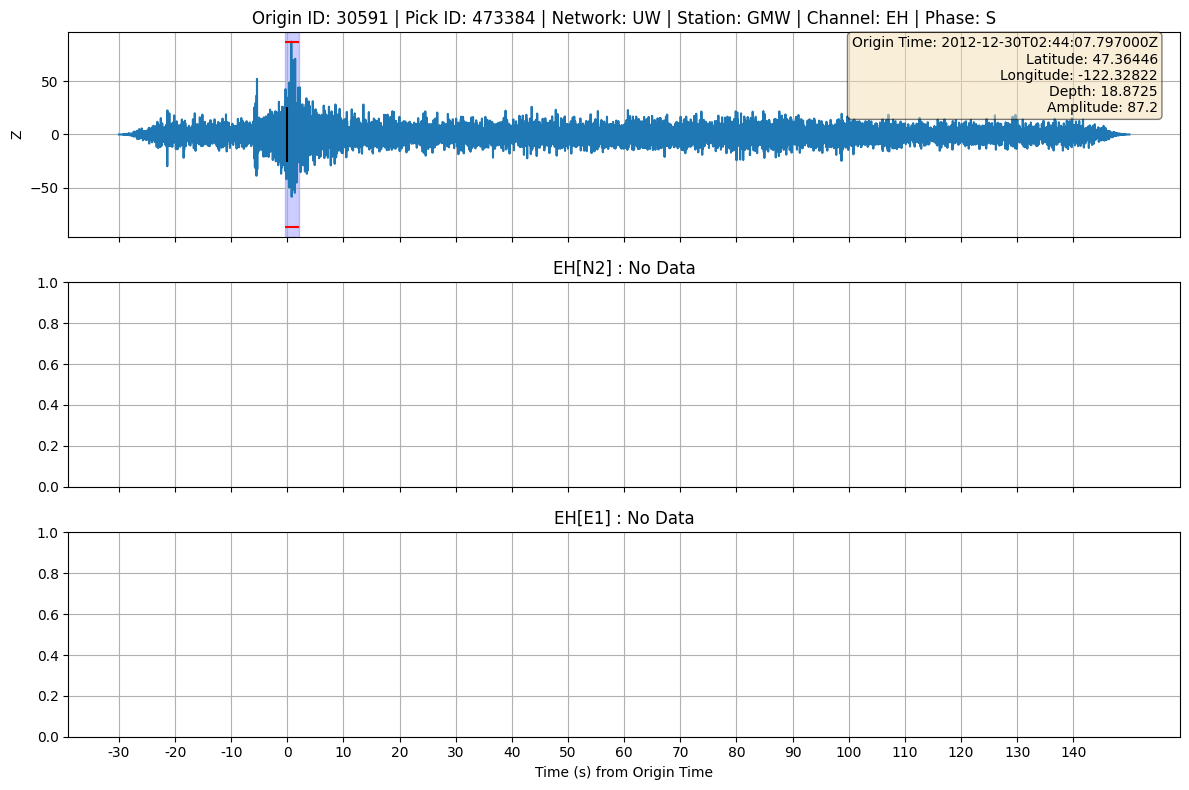

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


First print of max_amp 0
np.max(np.absolute(tr.data)) 304021.71620403905
Second print of max_amp 304021.71620403905
First print of max_amp 304021.71620403905
np.max(np.absolute(tr.data)) 137259.2240348196
Second print of max_amp 304021.71620403905
First print of max_amp 304021.71620403905
np.max(np.absolute(tr.data)) 227462.6738186316
Second print of max_amp 304021.71620403905


<Figure size 640x480 with 0 Axes>

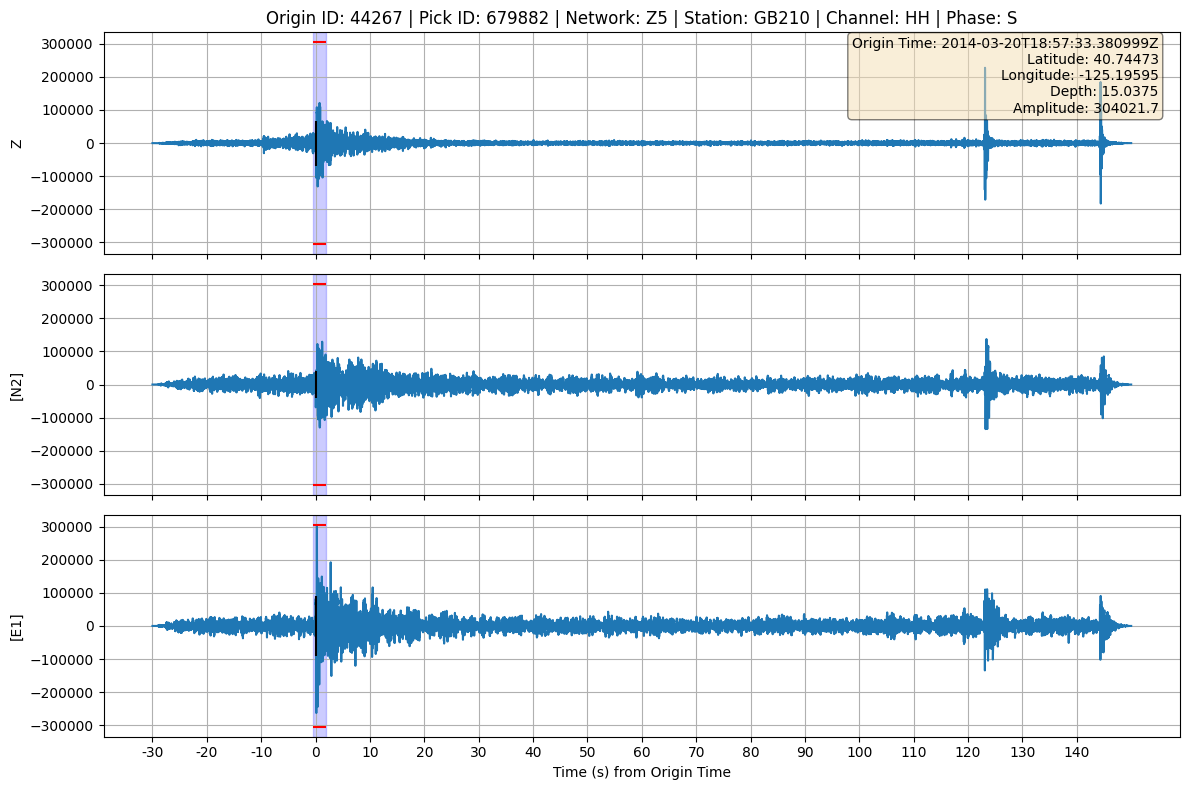

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


First print of max_amp 0
np.max(np.absolute(tr.data)) 339.0590508309574
Second print of max_amp 339.0590508309574
First print of max_amp 339.0590508309574
np.max(np.absolute(tr.data)) 518.2190686065077
Second print of max_amp 518.2190686065077
First print of max_amp 518.2190686065077
np.max(np.absolute(tr.data)) 445.9614883657541
Second print of max_amp 518.2190686065077


<Figure size 640x480 with 0 Axes>

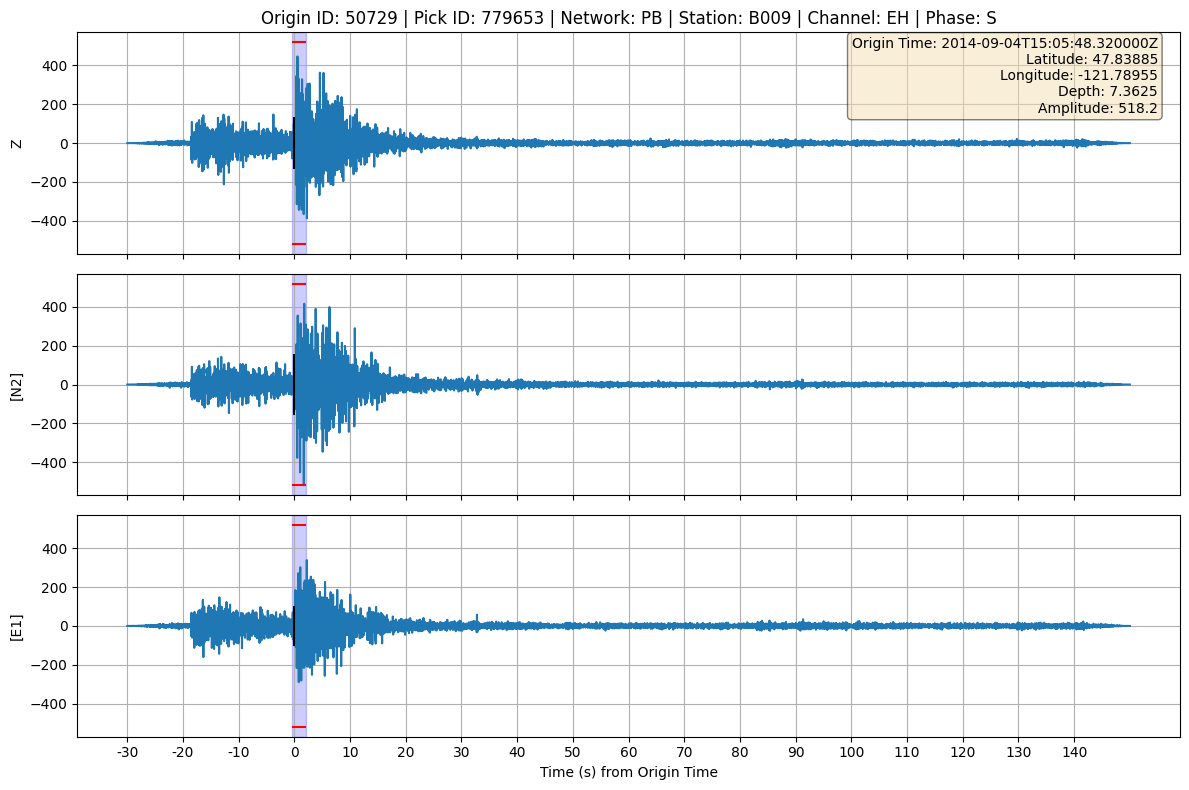

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


First print of max_amp 0
np.max(np.absolute(tr.data)) 46.106320411497805
Second print of max_amp 46.106320411497805
First print of max_amp 46.106320411497805
np.max(np.absolute(tr.data)) 82.50978832094961
Second print of max_amp 82.50978832094961
First print of max_amp 82.50978832094961
np.max(np.absolute(tr.data)) 129.62668416377136
Second print of max_amp 129.62668416377136


<Figure size 640x480 with 0 Axes>

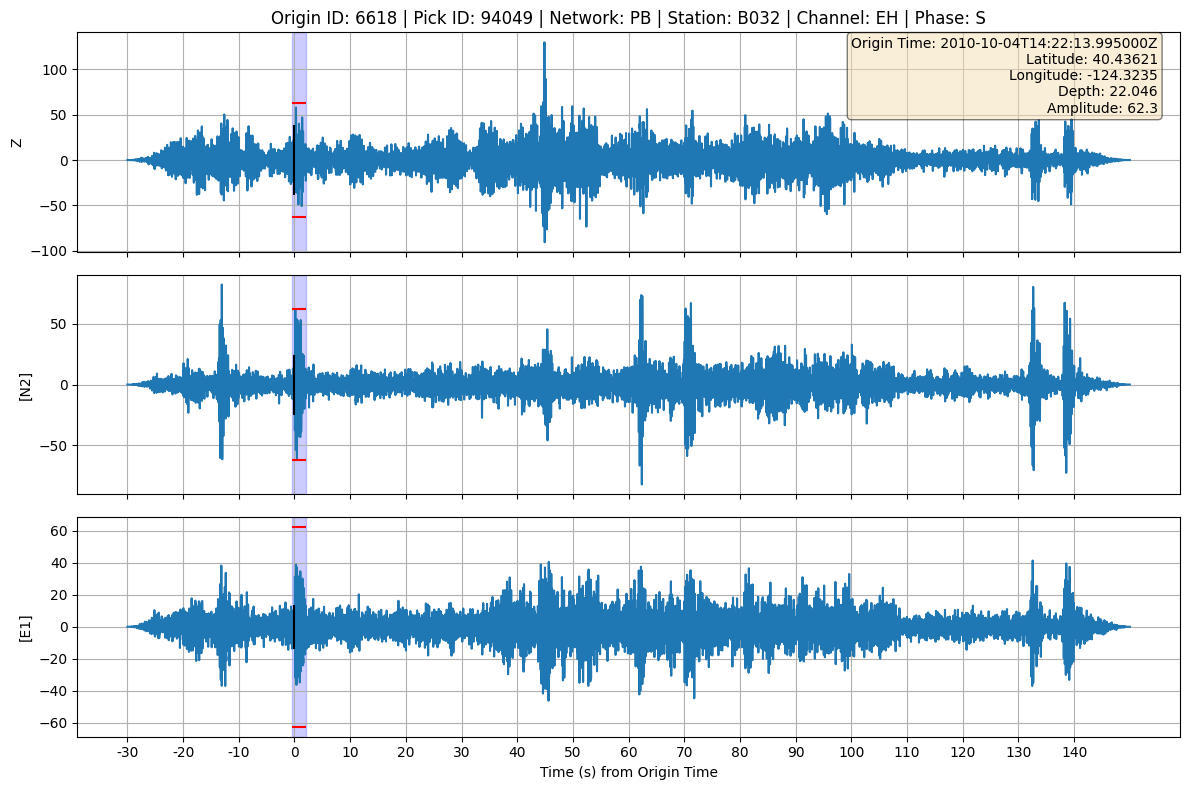

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


First print of max_amp 0
np.max(np.absolute(tr.data)) 273.85353266880384
Second print of max_amp 273.85353266880384
First print of max_amp 273.85353266880384
np.max(np.absolute(tr.data)) 374.6282512865524
Second print of max_amp 374.6282512865524
First print of max_amp 374.6282512865524
np.max(np.absolute(tr.data)) 123.49604075913555
Second print of max_amp 374.6282512865524


<Figure size 640x480 with 0 Axes>

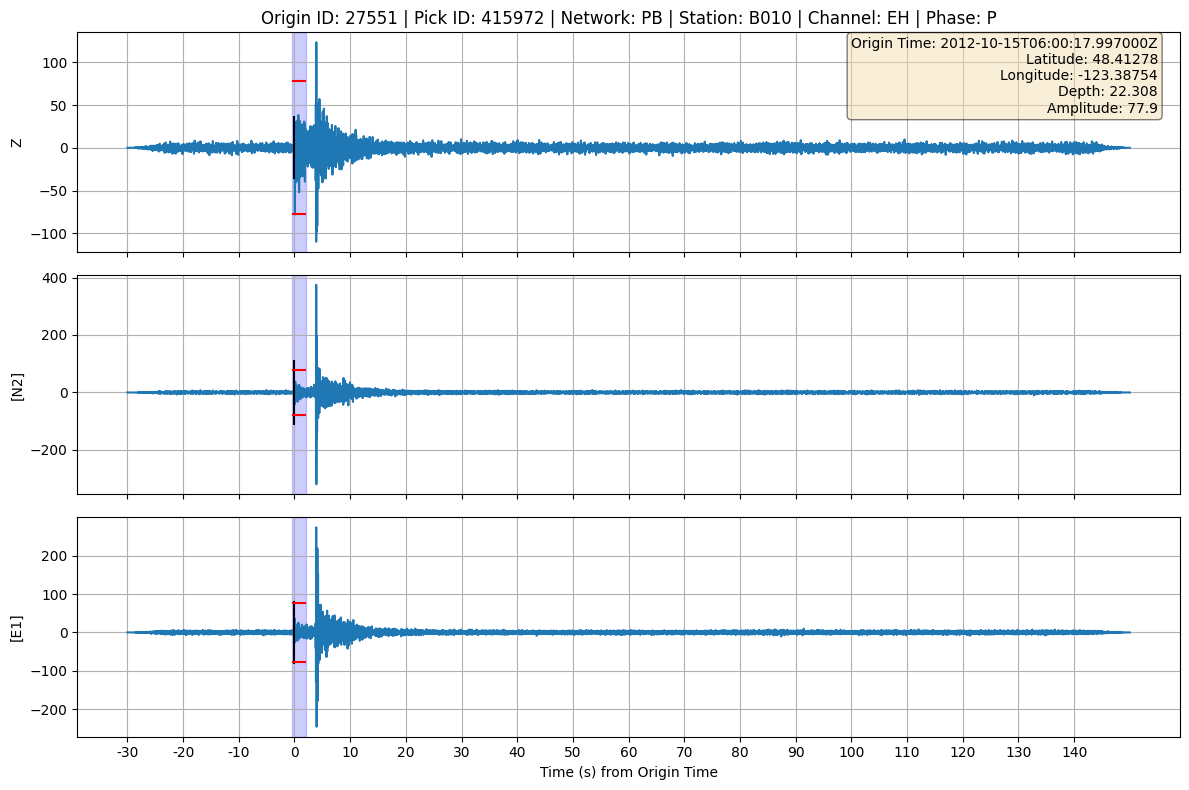

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


First print of max_amp 0
np.max(np.absolute(tr.data)) 26.64758893101203
Second print of max_amp 26.64758893101203
First print of max_amp 26.64758893101203
np.max(np.absolute(tr.data)) 38.772687602694674
Second print of max_amp 38.772687602694674
First print of max_amp 38.772687602694674
np.max(np.absolute(tr.data)) 10.916376310021562
Second print of max_amp 38.772687602694674


<Figure size 640x480 with 0 Axes>

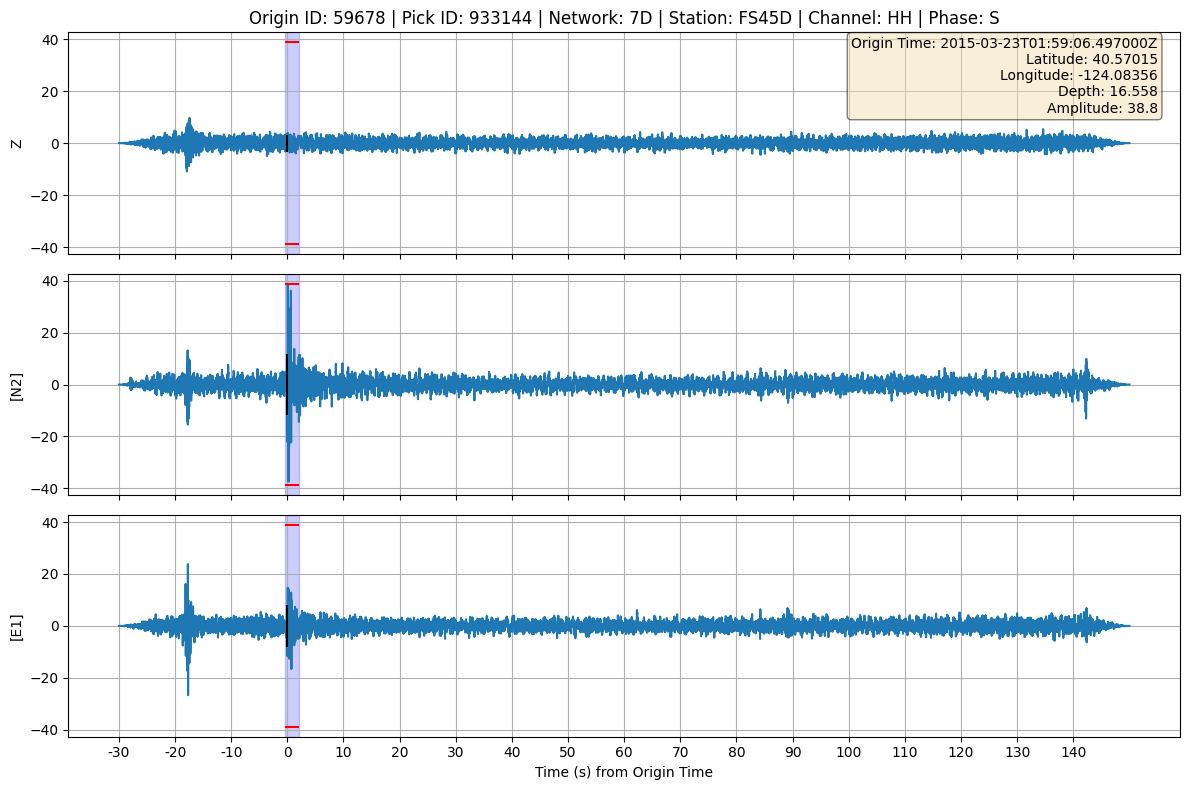

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


First print of max_amp 0
np.max(np.absolute(tr.data)) 84.63955850157511
Second print of max_amp 84.63955850157511


<Figure size 640x480 with 0 Axes>

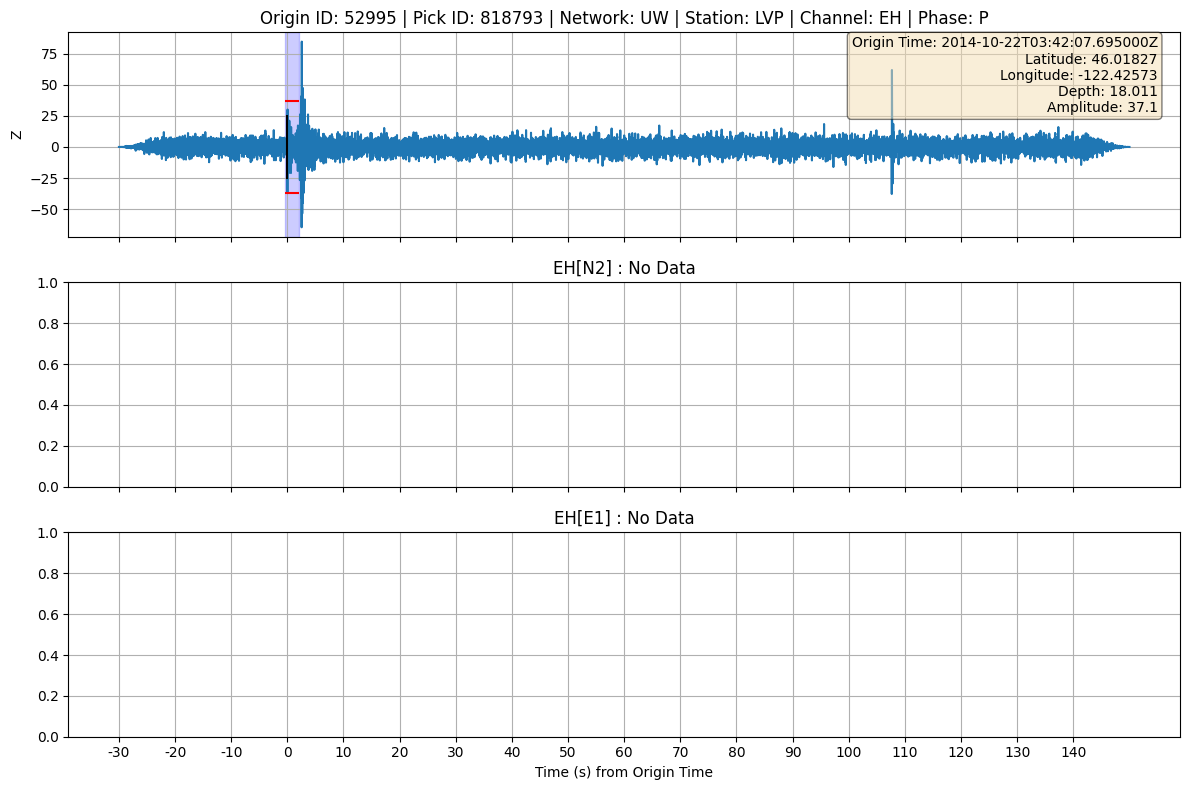

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


First print of max_amp 0
np.max(np.absolute(tr.data)) 446.2718281816346
Second print of max_amp 446.2718281816346


<Figure size 640x480 with 0 Axes>

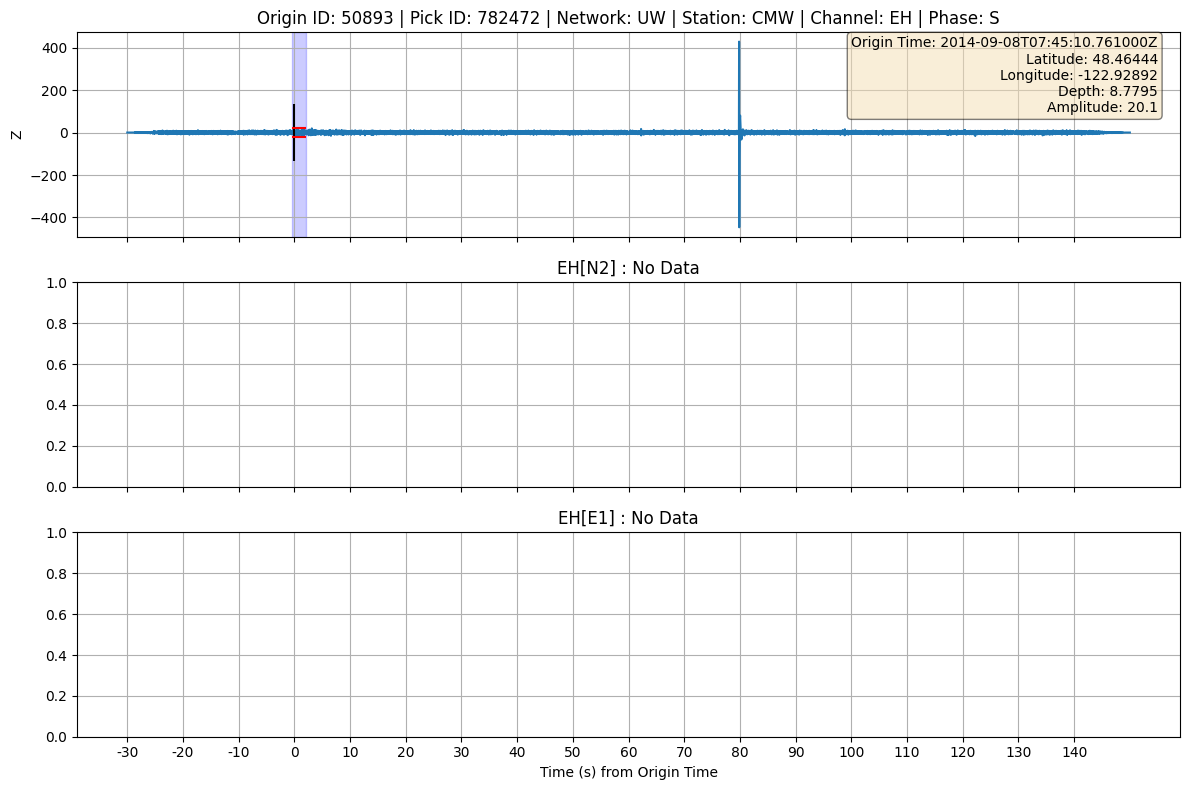

First print of max_amp 0
np.max(np.absolute(tr.data)) 187.8054905314204
Second print of max_amp 187.8054905314204
First print of max_amp 187.8054905314204
np.max(np.absolute(tr.data)) 152.69616051937413
Second print of max_amp 187.8054905314204
First print of max_amp 187.8054905314204
np.max(np.absolute(tr.data)) 85.48475859775054
Second print of max_amp 187.8054905314204


<Figure size 640x480 with 0 Axes>

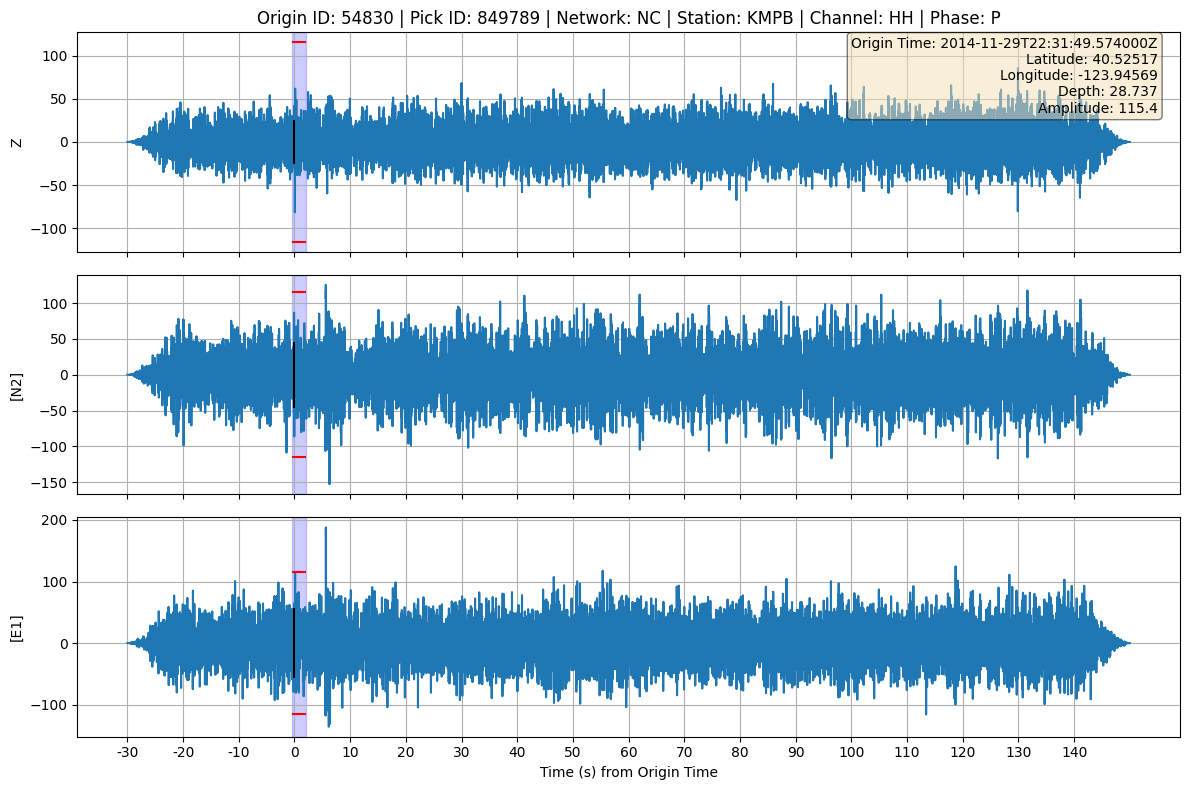

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


First print of max_amp 0
np.max(np.absolute(tr.data)) 14820.131259229607
Second print of max_amp 14820.131259229607
First print of max_amp 14820.131259229607
np.max(np.absolute(tr.data)) 10038.198857583646
Second print of max_amp 14820.131259229607
First print of max_amp 14820.131259229607
np.max(np.absolute(tr.data)) 12038.115867032384
Second print of max_amp 14820.131259229607


<Figure size 640x480 with 0 Axes>

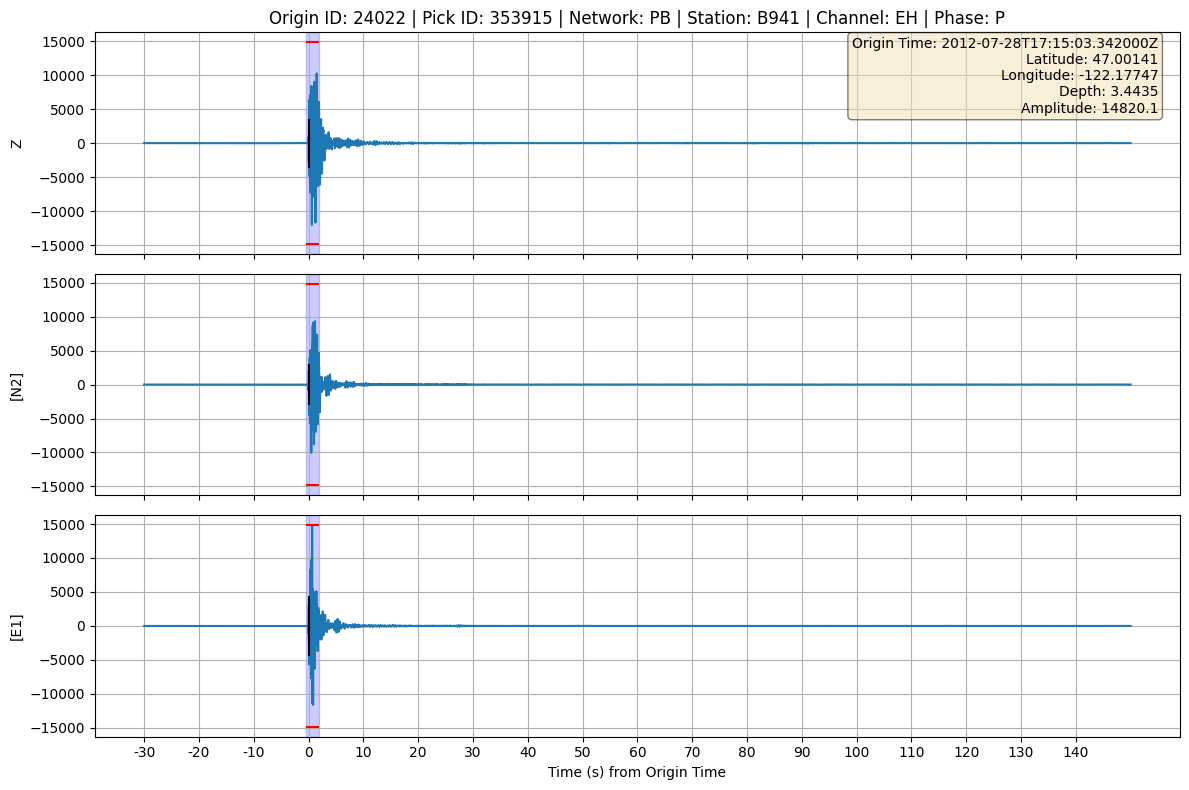

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


First print of max_amp 0
np.max(np.absolute(tr.data)) 433.06843858565765
Second print of max_amp 433.06843858565765
First print of max_amp 433.06843858565765
np.max(np.absolute(tr.data)) 413.26776756852803
Second print of max_amp 433.06843858565765
First print of max_amp 433.06843858565765
np.max(np.absolute(tr.data)) 390.3007458785294
Second print of max_amp 433.06843858565765


<Figure size 640x480 with 0 Axes>

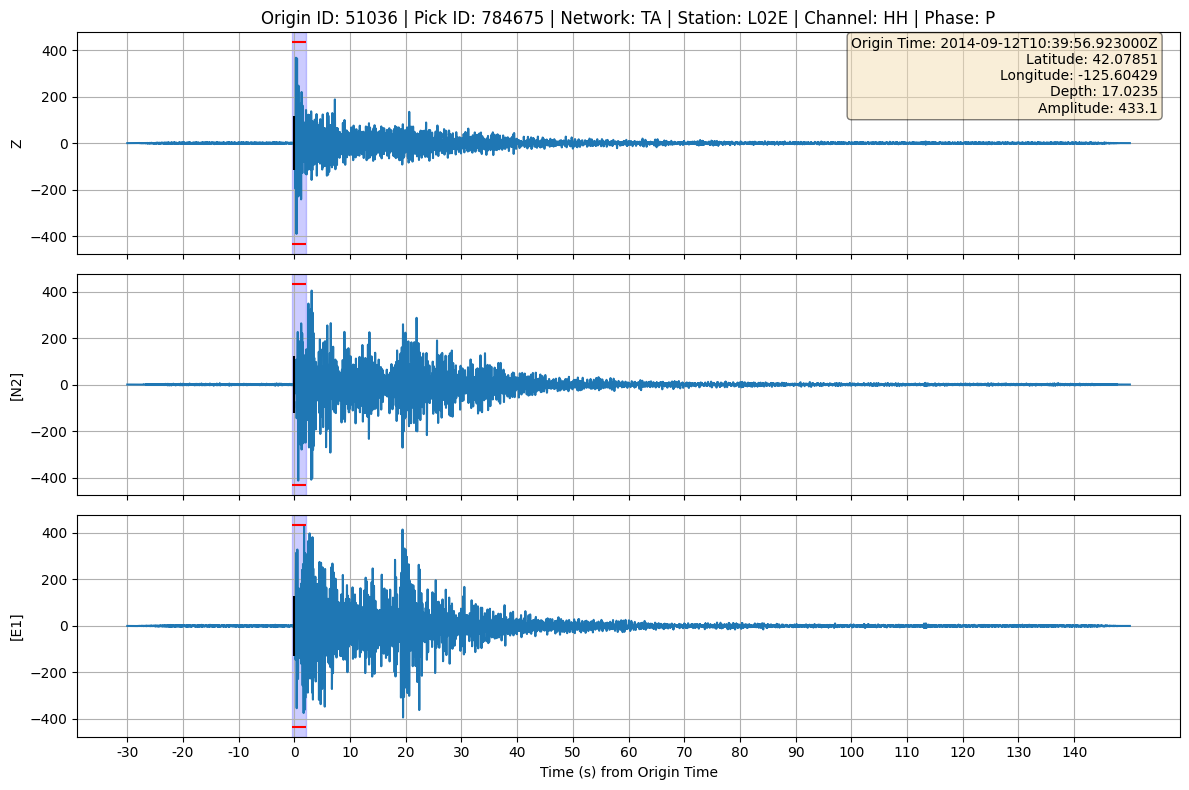

First print of max_amp 0
np.max(np.absolute(tr.data)) 19112.673549348307
Second print of max_amp 19112.673549348307
First print of max_amp 19112.673549348307
np.max(np.absolute(tr.data)) 17502.30937386222
Second print of max_amp 19112.673549348307
First print of max_amp 19112.673549348307
np.max(np.absolute(tr.data)) 9324.563395613717
Second print of max_amp 19112.673549348307


<Figure size 640x480 with 0 Axes>

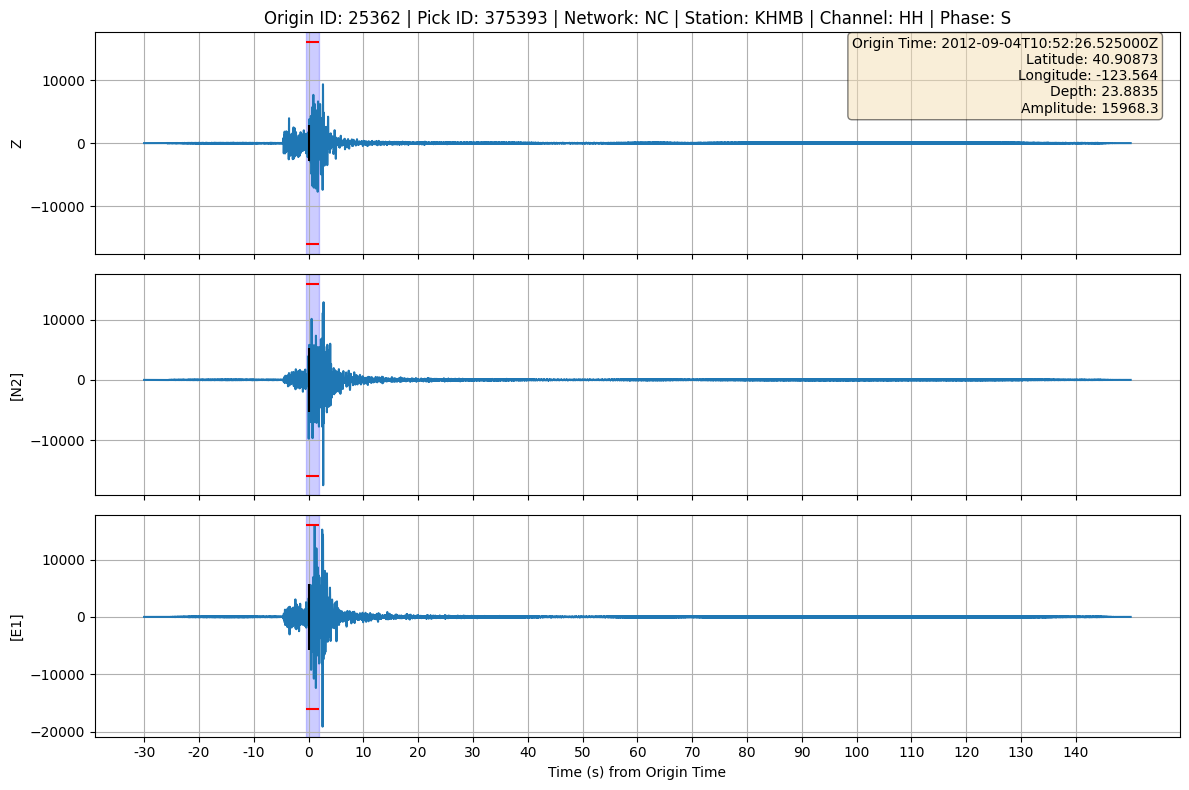

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


First print of max_amp 0
np.max(np.absolute(tr.data)) 86.64018774121946
Second print of max_amp 86.64018774121946
First print of max_amp 86.64018774121946
np.max(np.absolute(tr.data)) 80.57238604890058
Second print of max_amp 86.64018774121946
First print of max_amp 86.64018774121946
np.max(np.absolute(tr.data)) 93.27973218519573
Second print of max_amp 93.27973218519573


<Figure size 640x480 with 0 Axes>

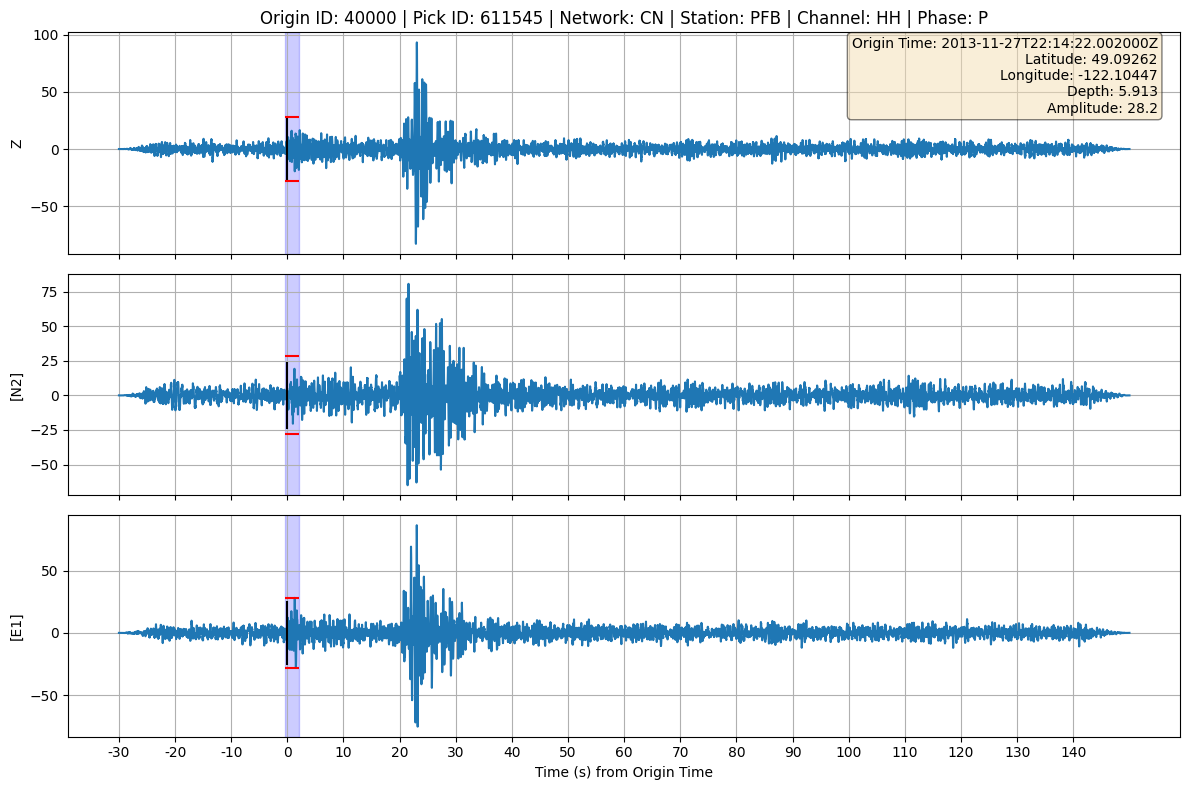

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


First print of max_amp 0
np.max(np.absolute(tr.data)) 660.1189281890961
Second print of max_amp 660.1189281890961
First print of max_amp 660.1189281890961
np.max(np.absolute(tr.data)) 766.039379191422
Second print of max_amp 766.039379191422
First print of max_amp 766.039379191422
np.max(np.absolute(tr.data)) 251.28181006626477
Second print of max_amp 766.039379191422


<Figure size 640x480 with 0 Axes>

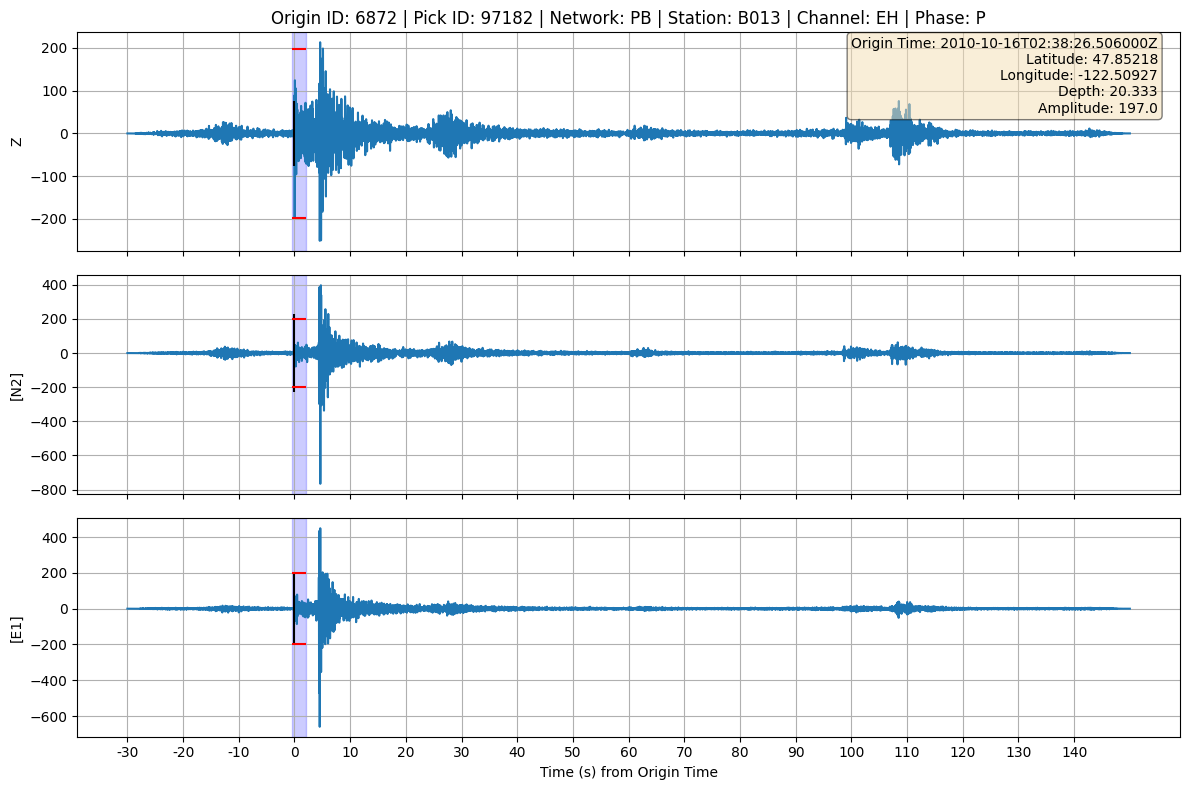

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


First print of max_amp 0
np.max(np.absolute(tr.data)) 66.34840887402868
Second print of max_amp 66.34840887402868
First print of max_amp 66.34840887402868
np.max(np.absolute(tr.data)) 62.5595101449456
Second print of max_amp 66.34840887402868
First print of max_amp 66.34840887402868
np.max(np.absolute(tr.data)) 37.1382144993883
Second print of max_amp 66.34840887402868


<Figure size 640x480 with 0 Axes>

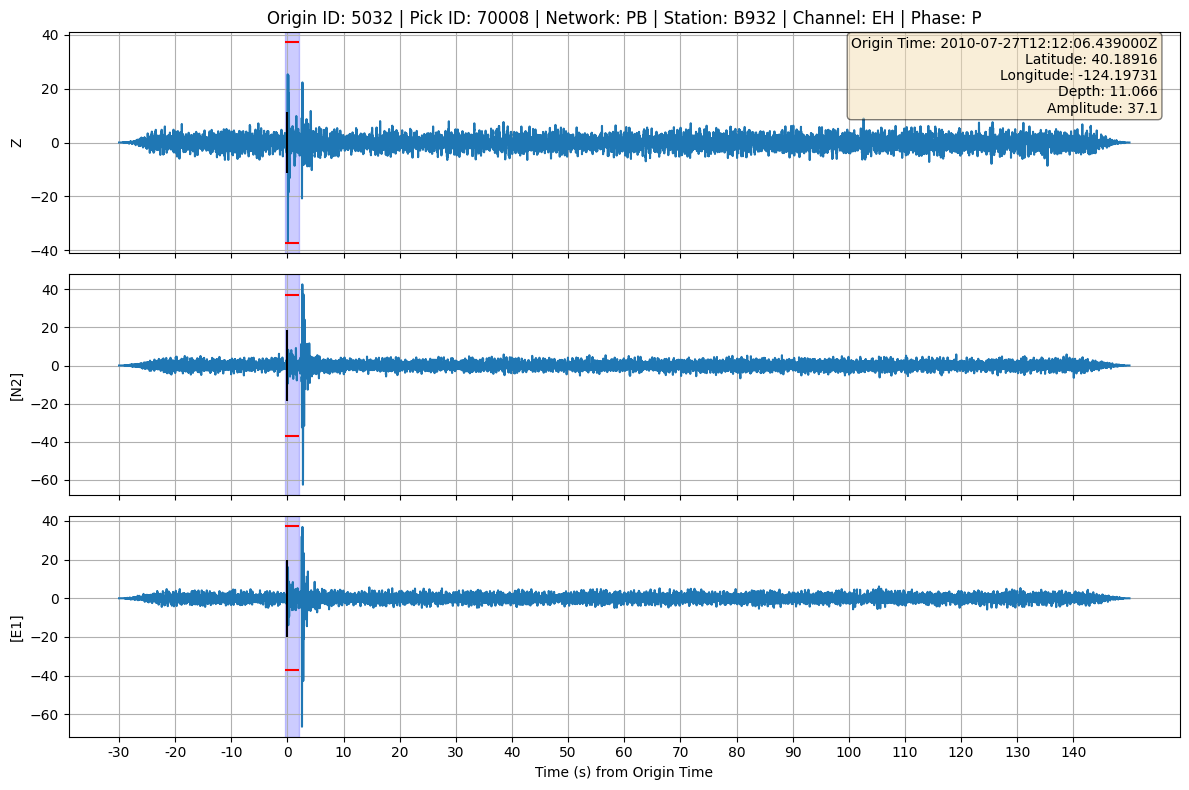

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


First print of max_amp 0
np.max(np.absolute(tr.data)) 16.89332337691213
Second print of max_amp 16.89332337691213
First print of max_amp 16.89332337691213
np.max(np.absolute(tr.data)) 13.457394787552001
Second print of max_amp 16.89332337691213
First print of max_amp 16.89332337691213
np.max(np.absolute(tr.data)) 12.01754271683718
Second print of max_amp 16.89332337691213


<Figure size 640x480 with 0 Axes>

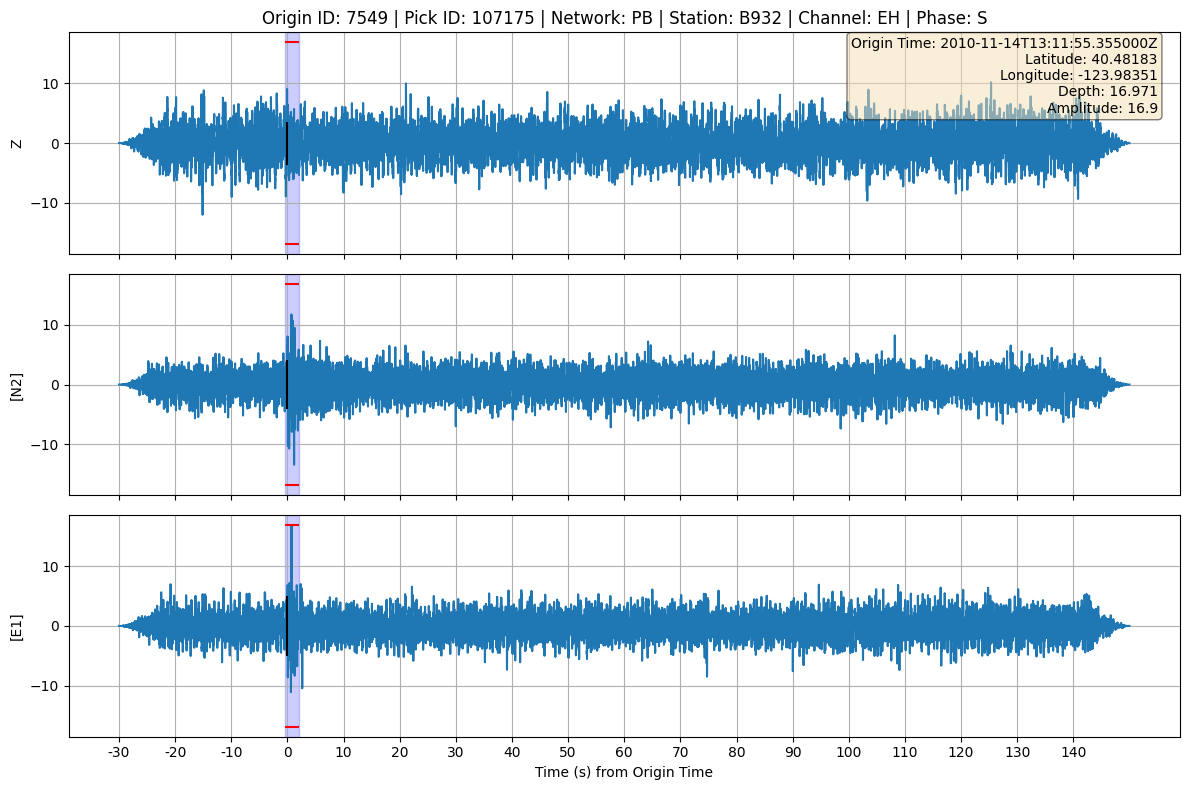

First print of max_amp 0
np.max(np.absolute(tr.data)) 145.45716181912374
Second print of max_amp 145.45716181912374
First print of max_amp 145.45716181912374
np.max(np.absolute(tr.data)) 123.17636588401689
Second print of max_amp 145.45716181912374
First print of max_amp 145.45716181912374
np.max(np.absolute(tr.data)) 99.31692893558322
Second print of max_amp 145.45716181912374


<Figure size 640x480 with 0 Axes>

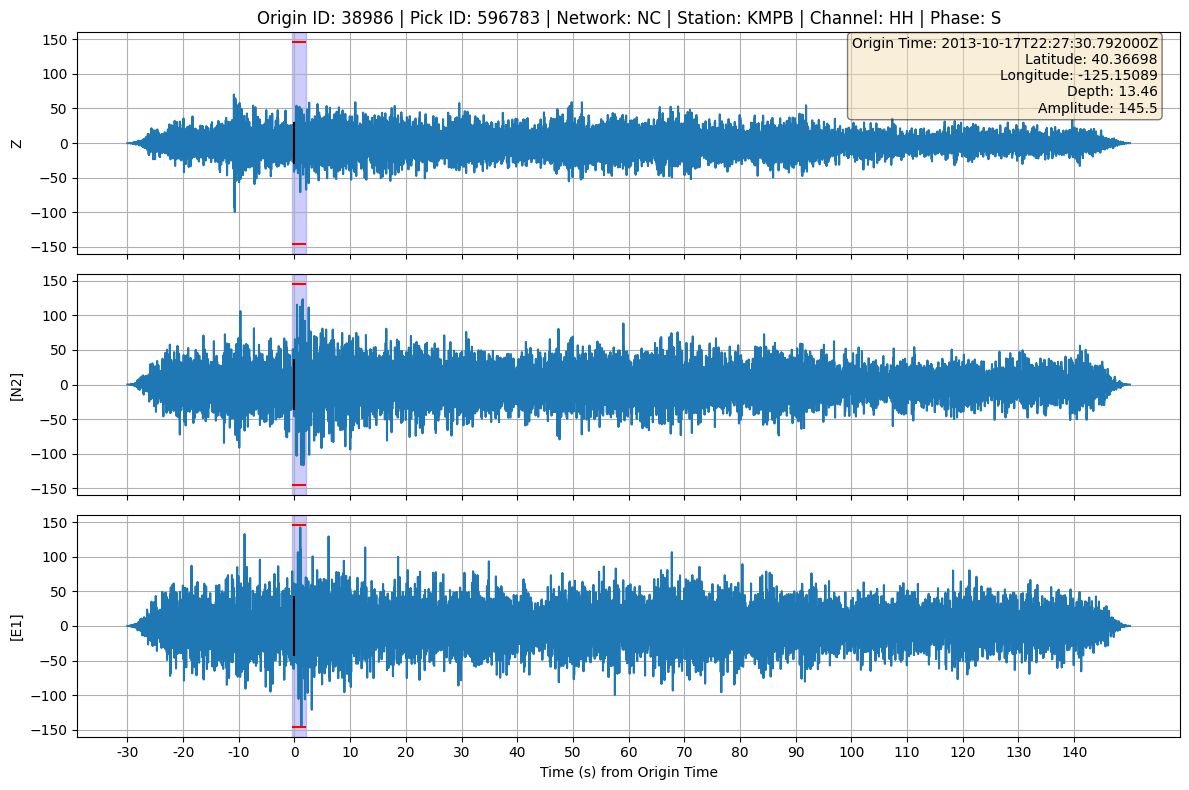

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


First print of max_amp 0
np.max(np.absolute(tr.data)) 1098.0188660119238
Second print of max_amp 1098.0188660119238
First print of max_amp 1098.0188660119238
np.max(np.absolute(tr.data)) 2987.410751232977
Second print of max_amp 2987.410751232977
First print of max_amp 2987.410751232977
np.max(np.absolute(tr.data)) 528.4938154101368
Second print of max_amp 2987.410751232977


<Figure size 640x480 with 0 Axes>

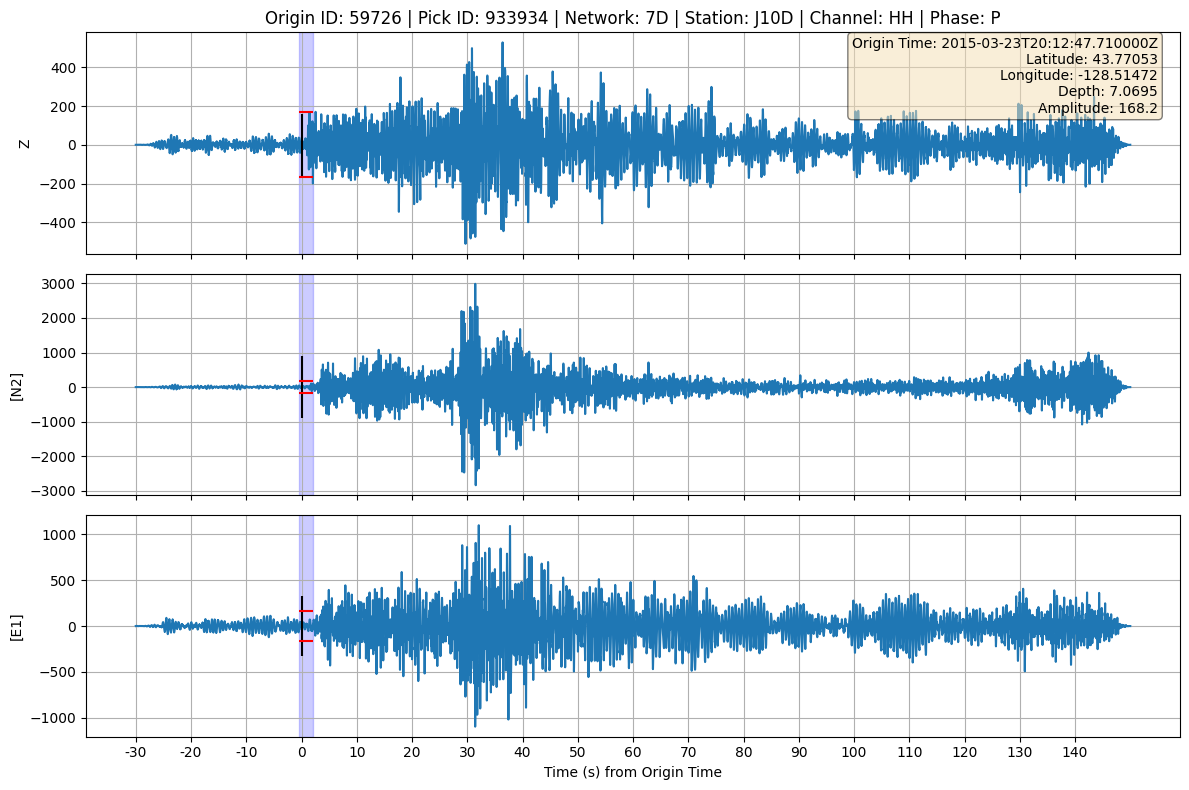

First print of max_amp 0
np.max(np.absolute(tr.data)) 74.85815696198412
Second print of max_amp 74.85815696198412
First print of max_amp 74.85815696198412
np.max(np.absolute(tr.data)) 61.90448314937008
Second print of max_amp 74.85815696198412
First print of max_amp 74.85815696198412
np.max(np.absolute(tr.data)) 47.35446853438158
Second print of max_amp 74.85815696198412


<Figure size 640x480 with 0 Axes>

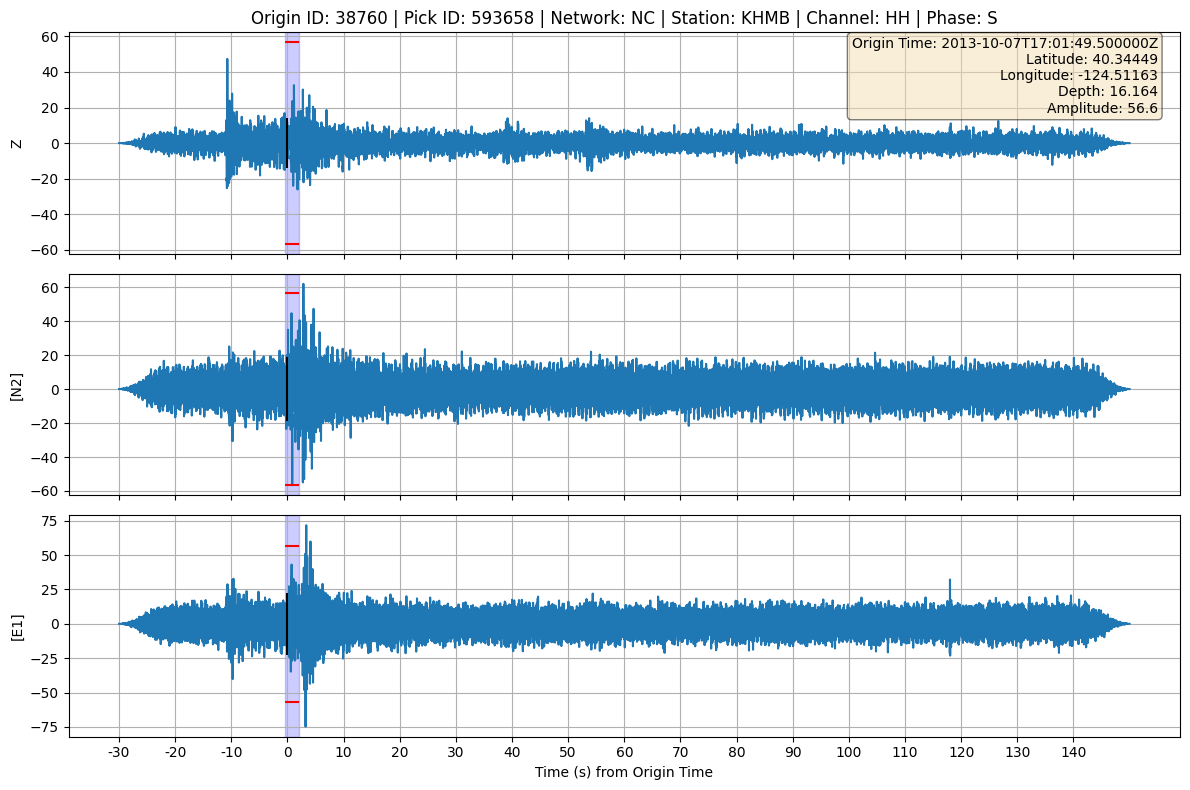

<Figure size 640x480 with 0 Axes>

In [14]:
plot_waveforms_for_picks(assigned_picks_df, dir_plots, ls_arid, window_before=window_before, window_after=window_after, window_amp_calc_before=window_amp_calc_before, window_amp_calc_after=window_amp_calc_after, source=source, scaling_factor_vline=scaling_factor_vline)


Plot the waveform around a specific pick

In [15]:
# Define the variables in the function
ls_arid = [985121]
window_before = 30 # in sec
window_after = 150 # in sec
window_amp_calc_before=0.5 # in sec
window_amp_calc_after=2 # in sec
source = 'pnwstore'
scaling_factor_vline = 0.3

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


First print of max_amp 0
np.max(np.absolute(tr.data)) 61.196878905625724
Second print of max_amp 61.196878905625724
First print of max_amp 61.196878905625724
np.max(np.absolute(tr.data)) 70.1760211739543
Second print of max_amp 70.1760211739543
First print of max_amp 70.1760211739543
np.max(np.absolute(tr.data)) 54.79294833043327
Second print of max_amp 70.1760211739543


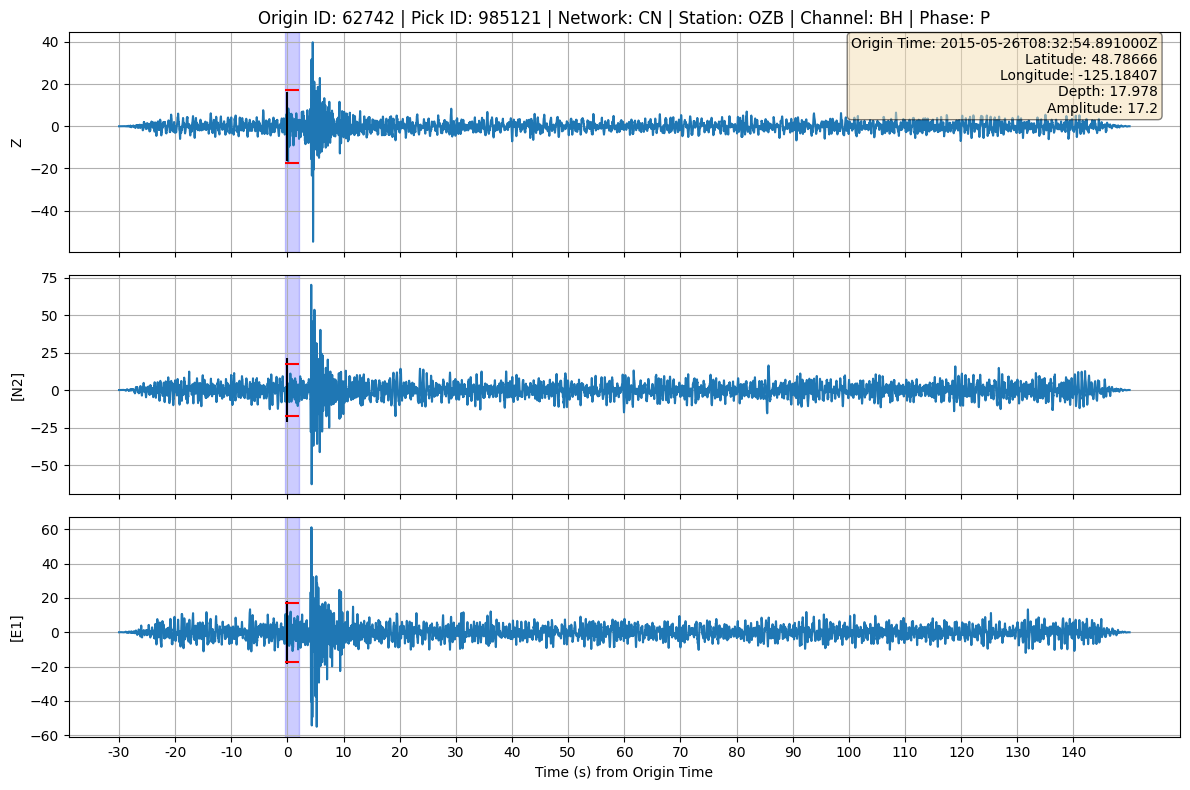

<Figure size 640x480 with 0 Axes>

In [16]:
plot_waveforms_for_picks(assigned_picks_df, dir_plots, ls_arid, window_before=window_before, window_after=window_after, window_amp_calc_before=window_amp_calc_before, window_amp_calc_after=window_amp_calc_after, source=source, scaling_factor_vline=scaling_factor_vline)

test

Large window

In [ ]:
# window_before = 0.5
# window_after = 2
# source = 'pnwstore'
# scaling_factor_vline = 0.3

In [ ]:
# arid = 63812
# pick_info = [] 


In [ ]:
# orid = assigned_picks_df.iloc[arid]['idx']
# pick_id = assigned_picks_df.iloc[arid]['arid']

# date, _time = assigned_picks_df.iloc[arid]['time'].split(' ')
# datetime_str = date+'T'+_time
# origin_time = UTCDateTime(datetime_str)  # Accept ISO string directly
# latitude = assigned_picks_df.iloc[arid]['latitude']
# longitude = assigned_picks_df.iloc[arid]['longitude']
# depth = assigned_picks_df.iloc[arid]['depth']

# # You may need to adjust these fields to match your DataFrame columns
# network = assigned_picks_df.iloc[arid]['station'].split('.')[0].strip()
# station = assigned_picks_df.iloc[arid]['station'].split('.')[1].strip()
# channel = "*H*"
# time_pick = UTCDateTime(assigned_picks_df.iloc[arid]['time_pick'])
# time_pick_origin  = UTCDateTime(assigned_picks_df.iloc[arid]['time_pick']) - origin_time
# starttime = time_pick - window_before 
# endtime = time_pick + window_after
# phase = assigned_picks_df.iloc[arid]['phase']
# amp = assigned_picks_df.iloc[arid]['Amplitude']

# # bulk.append((network, station, channel, starttime, endtime))
# pick_info.append({
#     'orid': orid,
#     'pick_id': pick_id,
#     'origin_time': origin_time,
#     'latitude': latitude,
#     'longitude': longitude,
#     'depth': depth,
#     'network': network,
#     'station': station,
#     'channel': channel,
#     'starttime': starttime,
#     'endtime': endtime,
#     'time_pick': time_pick,
#     'time_pick_origin': time_pick_origin,
#     'phase': phase,
#     'amp': amp
# })


# # Parameters to process waveforms
# new_sampling_rate = 100 # in Hz
# # freqmax = 15 # in Hz
# # freqmin = 4 # in Hz
# freq_highpass = 2 # in Hz


In [ ]:
# network = pick_info[0]['network']
# station = pick_info[0]['station']
# channel = pick_info[0]['channel']
# starttime = pick_info[0]['starttime']
# endtime = pick_info[0]['endtime']
# amp = pick_info[0]['amp']

# time_pick = pick_info[0]['time_pick']
# time_pick_origin = pick_info[0]['time_pick_origin']

# # fname = dir_plots+f"/{network}_{station}_arid_{info['pick_id']}.png"

# time.sleep(0.1)

# try:
#     st = get_waveforms(
#         network=network,
#         station=station,
#         channel=channel,
#         starttime=starttime,
#         endtime=endtime,
#         source=source
#     )
# except Exception as e:
#     print(f"Request failed: {e}")
#     st = Stream()

# time.sleep(0.1)

# # ---------------------------------------------------------
# # Select preferred channel family
# # ---------------------------------------------------------

# has_HH = bool(st.select(id=f'{network}.{station}..HH?'))
# has_BH = bool(st.select(id=f'{network}.{station}..BH?'))
# has_EH = bool(st.select(id=f'{network}.{station}..EH?'))

# sdata = Stream()

# if has_HH:
#     sdata += st.select(id=f'{network}.{station}..HH*')
#     channel_prefix = "HH"

# elif has_BH:
#     sdata += st.select(id=f'{network}.{station}..BH*')
#     channel_prefix = "BH"

# elif has_EH:
#     sdata += st.select(id=f'{network}.{station}..EH*')
#     channel_prefix = "EH"

# else:
#     print(f'No HH, BH, or EH data available at {network}.{station} at {time_pick}. Skipping.')
#     # continue

# #---Debug---#

# sdata.resample(new_sampling_rate)

# sdata.detrend(type='demean')
# sdata.taper(max_percentage=0.05)
# sdata.filter(type='highpass', freq=freq_highpass)

# max_amp = 0
# for tr in sdata:
#     print('First print of max_amp',max_amp)
#     print('np.max(np.absolute(tr.data))',np.max(np.absolute(tr.data)))
    
#     max_amp = max(max_amp, np.absolute(tr.data).max())
#     max_amp2 = max(max_amp, abs(tr.data).max())
    
    
#     print('Second print of max_amp',max_amp)

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


First print of max_amp 0
np.max(np.absolute(tr.data)) 906.33073526455
Second print of max_amp 906.33073526455


In [ ]:
# info = pick_info[0]

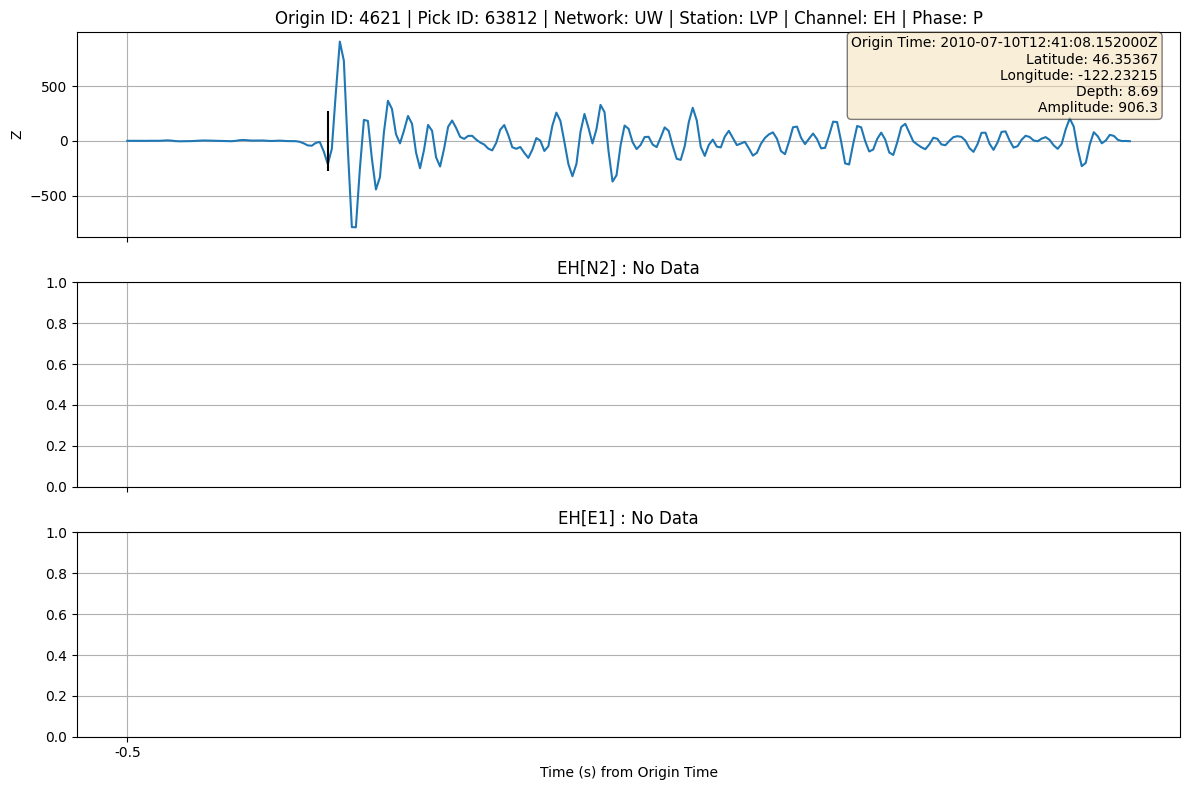

In [ ]:
# fig, axes = plt.subplots(
#     3,
#     1,
#     figsize=(12, 8),
#     sharex=True
# )

# component_list = ['Z', '[N2]', '[E1]']

# for ax, comp in zip(axes, component_list):

#     tr_select = sdata.select(channel=f"{channel_prefix}{comp}")

#     # -----------------------------------------------------
#     # Leave blank if component does not exist
#     # -----------------------------------------------------

#     if len(tr_select) == 0:

#         ax.set_title(f"{channel_prefix}{comp} : No Data")
#         ax.grid()

#         continue

#     tr = tr_select[0].copy()

#     # -----------------------------------------------------
#     # Process waveform
#     # -----------------------------------------------------

#     data = tr.data

#     times = np.linspace(
#         -window_before,
#         window_after,
#         tr.stats.npts
#     )

#     # print('times', times)
#     time_vline = 0

#     ymax = np.max(np.abs(data)) * scaling_factor_vline
#     ymin = -np.max(np.abs(data)) * scaling_factor_vline

#     # xmax = time_vline + window_amp_calc_after
#     # xmin = time_vline - window_amp_calc_before

#     # -----------------------------------------------------
#     # Plot waveform
#     # -----------------------------------------------------

#     # ax.axvspan(
#     #     xmin,
#     #     xmax,
#     #     color='b',
#     #     alpha=0.2
#     # )

#     ax.plot(times, data)

#     ax.vlines(
#         time_vline,
#         ymin,
#         ymax,
#         color='k',
#         linestyles='solid'
#     )

#     # ax.hlines(
#     #     amp,
#     #     xmax=xmax,
#     #     xmin=xmin,
#     #     color='r'
#     # )

#     # ax.hlines(
#     #     -amp,
#     #     xmax=xmax,
#     #     xmin=xmin,
#     #     color='r'
#     # )

#     ax.set_ylabel(comp)
#     ax.grid()

# # ---------------------------------------------------------
# # Common formatting
# # ---------------------------------------------------------

# axes[0].set_title(
#     f"Origin ID: {info['orid']} | "
#     f"Pick ID: {info['pick_id']} | "
#     f"Network: {info['network']} | "
#     f"Station: {info['station']} | "
#     f"Channel: {channel_prefix} | "
#     f"Phase: {info['phase']}"
# )

# axes[-1].set_xlabel("Time (s) from Origin Time")

# ticks = np.arange(-window_before, window_after, 10)
# str_ticks = [str(t) for t in ticks]

# axes[-1].set_xticks(ticks=ticks, labels=str_ticks)

# # Event information box
# info_text = (
#     f"Origin Time: {info['origin_time']}\n"
#     f"Latitude: {info['latitude']}\n"
#     f"Longitude: {info['longitude']}\n"
#     f"Depth: {info['depth']}\n"
#     f"Amplitude: {np.round(amp, decimals=1)}"
# )

# props = dict(
#     boxstyle='round',
#     facecolor='wheat',
#     alpha=0.5
# )

# axes[0].text(
#     0.98,
#     0.98,
#     info_text,
#     transform=axes[0].transAxes,
#     fontsize=10,
#     verticalalignment='top',
#     horizontalalignment='right',
#     bbox=props
# )

# plt.tight_layout()
# plt.show()
# # plt.savefig(fname=fname, format='png')
# plt.close(fig)

# time.sleep(0.1)

In [ ]:
# max_amp2

493.1537290537199

In [ ]:
# assigned_picks_df.loc[assigned_picks_df['arid']==513769]['Amplitude']

513769    493.153729
Name: Amplitude, dtype: float64

In [ ]:
# assigned_picks_df.loc[assigned_picks_df['arid']==513769]['Amplitude'].values[0]

493.1537290537199

In [ ]:
# orid = row['idx'].values[0]
# pick_id = row['arid'].values[0]

# date, _time = row['time'].values[0].split(' ')
# datetime_str = date+'T'+_time
# origin_time = UTCDateTime(datetime_str)  # Accept ISO string directly
# latitude = row['latitude'].values[0]
# longitude = row['longitude'].values[0]
# depth = row['depth'].values[0]

# # You may need to adjust these fields to match your DataFrame columns
# network = row['station'].values[0].split('.')[0].strip()
# station = row['station'].values[0].split('.')[1].strip()
# channel = "*H*"
# starttime = time_pick - window_before 
# endtime = origin_time + window_after
# time_pick = UTCDateTime(row['time_pick'].values[0])
# time_pick_origin  = UTCDateTime(row['time_pick'].values[0]) - origin_time
# phase = row['phase'].values[0]
# amp = row['Amplitude'].values[0]

# # MOD
# # bulk.append((network, station, channel, starttime, endtime))
# # end MOD 

# pick_info.append({
#     'orid': orid,
#     'pick_id': pick_id,
#     'origin_time': origin_time,
#     'latitude': latitude,
#     'longitude': longitude,
#     'depth': depth,
#     'network': network,
#     'station': station,
#     'channel': channel,
#     'starttime': starttime,
#     'endtime': endtime,
#     'time_pick': time_pick,
#     'time_pick_origin': time_pick_origin,
#     'phase': phase,
#     'amp': amp
# })


# # Parameters to process waveforms
# new_sampling_rate = 100 # in Hz
# # freqmax = 15 # in Hz
# # freqmin = 4 # in Hz
# freq_highpass = 2 # in Hz


In [ ]:
# pick_info_row = pick_info[0]

# network = pick_info_row['network']
# station = pick_info_row['station']
# channel = pick_info_row['channel']
# starttime = pick_info_row['starttime']
# endtime = pick_info_row['endtime']
# amp = pick_info_row['amp']

# time_pick = pick_info_row['time_pick']
# time_pick_origin = pick_info_row['time_pick_origin']

# # MOD
# # fname = dir_plots+f"/{network}_{station}_arid_{info['pick_id']}.png"

# time.sleep(0.1)

# try:
#     st = get_waveforms(
#         network=network,
#         station=station,
#         channel=channel,
#         starttime=starttime,
#         endtime=endtime,
#         source=source
#     )
# except Exception as e:
#     print(f"Request failed: {e}")
#     st = Stream()

# time.sleep(0.1)

# # ---------------------------------------------------------
# # Select preferred channel family
# # ---------------------------------------------------------

# has_HH = bool(st.select(id=f'{network}.{station}..HH?'))
# has_BH = bool(st.select(id=f'{network}.{station}..BH?'))
# has_EH = bool(st.select(id=f'{network}.{station}..EH?'))

# sdata = Stream()

# if has_HH:
#     sdata += st.select(id=f'{network}.{station}..HH*')
#     channel_prefix = "HH"

# elif has_BH:
#     sdata += st.select(id=f'{network}.{station}..BH*')
#     channel_prefix = "BH"

# elif has_EH:
#     sdata += st.select(id=f'{network}.{station}..EH*')
#     channel_prefix = "EH"

# else:
#     print(f'No HH, BH, or EH data available at {network}.{station} at {time_pick}. Skipping.')


# #---Debug---#

# # MOD
# if len(sdata) != 0:
#     sdata.resample(new_sampling_rate)

#     sdata.detrend(type='demean')
#     sdata.taper(max_percentage=0.05)
#     sdata.filter(type='highpass', freq=freq_highpass)

#     max_amp = 0
#     for tr in sdata:
#         print('First print of max_amp',max_amp)
#         print('np.max(np.absolute(tr.data))',np.max(np.absolute(tr.data)))
        
#         max_amp = max(max_amp, np.absolute(tr.data).max())
        
#         print('Second print of max_amp',max_amp)

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


First print of max_amp 0
np.max(np.absolute(tr.data)) 61.196878905625724
Second print of max_amp 61.196878905625724
First print of max_amp 61.196878905625724
np.max(np.absolute(tr.data)) 70.1760211739543
Second print of max_amp 70.1760211739543
First print of max_amp 70.1760211739543
np.max(np.absolute(tr.data)) 54.79294833043327
Second print of max_amp 70.1760211739543


Small window

In [ ]:
# source = 'pnwstore'
# scaling_factor_vline = 0.3
# window_before_calc_amplitude = 0.5
# window_after_calc_amplitude = 2

In [26]:
# arid = 870825

# pick_info = [] 
# row = assigned_picks_df.loc[assigned_picks_df['arid']==arid]
# orid = row['idx'].values[0]
# pick_id = row['arid'].values[0]

# date, _time = row['time'].values[0].split(' ')
# datetime_str = date+'T'+_time
# origin_time = UTCDateTime(datetime_str)  # Accept ISO string directly
# latitude = row['latitude'].values[0]
# longitude = row['longitude'].values[0]
# depth = row['depth'].values[0]

# # You may need to adjust these fields to match your DataFrame columns
# network = row['station'].values[0].split('.')[0].strip()
# station = row['station'].values[0].split('.')[1].strip()
# channel = "*H*"
# starttime = origin_time - window_before_calc_amplitude 
# endtime = origin_time + window_after_calc_amplitude
# time_pick = UTCDateTime(row['time_pick'].values[0])
# time_pick_origin  = UTCDateTime(row['time_pick'].values[0]) - origin_time
# phase = row['phase'].values[0]
# amp = row['Amplitude'].values[0]

# # MOD
# # bulk.append((network, station, channel, starttime, endtime))
# # end MOD 

# pick_info.append({
#     'orid': orid,
#     'pick_id': pick_id,
#     'origin_time': origin_time,
#     'latitude': latitude,
#     'longitude': longitude,
#     'depth': depth,
#     'network': network,
#     'station': station,
#     'channel': channel,
#     'starttime': starttime,
#     'endtime': endtime,
#     'time_pick': time_pick,
#     'time_pick_origin': time_pick_origin,
#     'phase': phase,
#     'amp': amp
# })


# # Parameters to process waveforms
# new_sampling_rate = 100 # in Hz
# # freqmax = 15 # in Hz
# # freqmin = 4 # in Hz
# freq_highpass = 2 # in Hz


In [27]:
# pick_info_row = pick_info[0]

# network = pick_info_row['network']
# station = pick_info_row['station']
# channel = pick_info_row['channel']
# starttime = pick_info_row['starttime']
# endtime = pick_info_row['endtime']
# amp = pick_info_row['amp']

# time_pick = pick_info_row['time_pick']
# time_pick_origin = pick_info_row['time_pick_origin']

# # MOD
# # fname = dir_plots+f"/{network}_{station}_arid_{info['pick_id']}.png"

# time.sleep(0.1)

# try:
#     st = get_waveforms(
#         network=network,
#         station=station,
#         channel=channel,
#         starttime=starttime,
#         endtime=endtime,
#         source=source
#     )
# except Exception as e:
#     print(f"Request failed: {e}")
#     st = Stream()

# time.sleep(0.1)

# # ---------------------------------------------------------
# # Select preferred channel family
# # ---------------------------------------------------------

# has_HH = bool(st.select(id=f'{network}.{station}..HH?'))
# has_BH = bool(st.select(id=f'{network}.{station}..BH?'))
# has_EH = bool(st.select(id=f'{network}.{station}..EH?'))

# sdata = Stream()

# if has_HH:
#     sdata += st.select(id=f'{network}.{station}..HH*')
#     channel_prefix = "HH"

# elif has_BH:
#     sdata += st.select(id=f'{network}.{station}..BH*')
#     channel_prefix = "BH"

# elif has_EH:
#     sdata += st.select(id=f'{network}.{station}..EH*')
#     channel_prefix = "EH"

# else:
#     print(f'No HH, BH, or EH data available at {network}.{station} at {time_pick}. Skipping.')


# #---Debug---#

# # MOD
# if len(sdata) != 0:
#     sdata.resample(new_sampling_rate)

#     sdata.detrend(type='demean')
#     sdata.taper(max_percentage=0.05)
#     sdata.filter(type='highpass', freq=freq_highpass)

#     max_amp = 0
#     for tr in sdata:
#         print('First print of max_amp',max_amp)
#         print('np.max(np.absolute(tr.data))',np.max(np.absolute(tr.data)))
        
#         max_amp = max(max_amp, np.absolute(tr.data).max())
        
#         print('Second print of max_amp',max_amp)

First print of max_amp 0
np.max(np.absolute(tr.data)) 68.66065904679301
Second print of max_amp 68.66065904679301
First print of max_amp 68.66065904679301
np.max(np.absolute(tr.data)) 120.59808386908479
Second print of max_amp 120.59808386908479
First print of max_amp 120.59808386908479
np.max(np.absolute(tr.data)) 35.79806550738638
Second print of max_amp 120.59808386908479


Script

In [87]:
source = 'pnwstore'
scaling_factor_vline = 0.3
window_before = 30
window_after = 150
window_before_calc_amplitude = 0.5
window_after_calc_amplitude = 2

freq_highpass = 2 # in Hz
new_sampling_rate = 100 # in Hz

In [92]:
arid = 985121
row = assigned_picks_df.loc[assigned_picks_df['arid']==arid]


# Define the arguments 
date, _time = row['time'].values[0].split(' ')
datetime_str = date+'T'+_time
origin_time = UTCDateTime(datetime_str)  # Accept ISO string directly

time_pick_str = row['time_pick'].values[0]
time_pick = UTCDateTime(time_pick_str)  # Accept ISO string directly

network = row['station'].values[0].split('.')[0].strip()
station = row['station'].values[0].split('.')[1].strip()
channel = '*H*'

# # MOD
starttime = time_pick - window_before 
endtime = time_pick + window_after
# # end MOD

# Inserted
starttime_trim = time_pick - window_before_calc_amplitude 
endtime_trim = time_pick + window_after_calc_amplitude

# # Print the number of items in amplitudes
# print('len(amplitudes)',len(amplitudes))    

# Request a waveform
time.sleep(0.1)

try:
    st = get_waveforms(network=network, station=station, channel=channel,
                        starttime=starttime, endtime=endtime,
                        source=source)
except Exception as e:
    print(f"Request failed: {e}")

    # MOD
    # # Save amplitude to the output DataFrame and CSV on the fly
    # amp = np.nan
    # amplitudes.append(amp)

    # # Save skipped info to CSV
    # skipped_info = {
    #     'network': network,
    #     'station': station,
    #     'channel': channel,
    #     'origin_time': origin_time,
    #     'time_pick': time_pick,
    #     'starttime': starttime,
    #     'endtime': endtime,
    #     'reason': f'Request failed: {e}'
    # }
    # df_skipped = pd.DataFrame([skipped_info])
    # if not os.path.isfile(skipped_csv_path):
    #     df_skipped.to_csv(skipped_csv_path, mode='w', header=True, index=False)
    # else:
    #     df_skipped.to_csv(skipped_csv_path, mode='a', header=False, index=False)
    # end MOD

    # continue
    

# time.sleep(0.1)


# Create a new stream
sdata = Stream()

# Check if loaded data have a vertical component (minimum requirement)
has_Z = bool(st.select(id=f'{network}.{station}..??Z'))
# Check for the presence of HH, BH, and EH channels
has_HH = bool(st.select(id=f'{network}.{station}..HH?'))
has_BH = bool(st.select(id=f'{network}.{station}..BH?'))
has_EH = bool(st.select(id=f'{network}.{station}..EH?'))

if not has_Z:
    e = f'No Vertical Component Data Present at {network}.{station} with HHZ, BHZ or EHZ channels at {time_pick_str}. Skipping'
    print(e)

    # MOD
    # # Save amplitude in the list
    # amp = np.nan
    # amplitudes.append(amp)

    # # Save skipped info to CSV
    # skipped_info = {
    #     'network': network,
    #     'station': station,
    #     'channel': channel,
    #     'origin_time': origin_time,
    #     'time_pick': time_pick,
    #     'starttime': starttime,
    #     'endtime': endtime,
    #     'reason': f'Request failed: {e}'
    # }
    # df_skipped = pd.DataFrame([skipped_info])
    # if not os.path.isfile(skipped_csv_path):
    #     df_skipped.to_csv(skipped_csv_path, mode='w', header=True, index=False)
    # else:
    #     df_skipped.to_csv(skipped_csv_path, mode='a', header=False, index=False)
    # end MOD

    # continue

# Apply selection logic based on channel presence
if has_HH:
    # If all HH, BH, and EH, channels are present, select only HH
    sdata += st.select(id=f'{network}.{station}..HH*')
elif has_BH:
    # If BH and EH channels are present, select only BH
    sdata += st.select(id=f'{network}.{station}..BH*')
elif has_EH:
    # If only EH channels are present, select only EH
    # NTS: This may result in getting only vertical component data - EH? is used for PNSN analog stations
    # NTS: This may also be tricky for pulling full day-volumes because the sampling rate shifts for
    #      analog stations due to the remote digitization scheme used with analog stations
    sdata += st.select(id=f'{network}.{station}..EH*')
else:
    e = f'No data available at {network}.{station} with HHZ, BHZ or EHZ channels at {time_pick_str}. Skipping.'
    print(e)

    # MOD
    # # Save amplitude to the output DataFrame and CSV on the fly
    # amp = np.nan
    # amplitudes.append(amp)

    # # Save skipped info to CSV
    # skipped_info = {
    #     'network': network,
    #     'station': station,
    #     'channel': channel,
    #     'origin_time': origin_time,
    #     'time_pick': time_pick,
    #     'starttime': starttime,
    #     'endtime': endtime,
    #     'reason': f'Request failed: {e}'
    # }
    # df_skipped = pd.DataFrame([skipped_info])
    # if not os.path.isfile(skipped_csv_path):
    #     df_skipped.to_csv(skipped_csv_path, mode='w', header=True, index=False)
    # else:
    #     df_skipped.to_csv(skipped_csv_path, mode='a', header=False, index=False)
    # continue
    # end MOD

# Resample
sdata.resample(new_sampling_rate)
    
# Apply highpass filter
sdata.detrend(type='demean')
sdata.taper(max_percentage=0.05)
sdata.filter(type='highpass', freq=freq_highpass)

trimmed_data = sdata.copy().trim(starttime=starttime_trim, endtime=endtime_trim)

max_amp = 0
for tr in trimmed_data:
    print(trimmed_data)
    print('First print of max_amp',max_amp)
    print('np.max(np.absolute(tr.data))',np.max(np.absolute(tr.data)))
    
    max_amp = max(max_amp, np.absolute(tr.data).max())
    
    print('Second print of max_amp',max_amp)


PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


3 Trace(s) in Stream:
CN.OZB..BHE | 2015-05-26T08:32:59.575000Z - 2015-05-26T08:33:02.075000Z | 100.0 Hz, 251 samples
CN.OZB..BHN | 2015-05-26T08:32:59.575000Z - 2015-05-26T08:33:02.075000Z | 100.0 Hz, 251 samples
CN.OZB..BHZ | 2015-05-26T08:32:59.575000Z - 2015-05-26T08:33:02.075000Z | 100.0 Hz, 251 samples
First print of max_amp 0
np.max(np.absolute(tr.data)) 12.01627691436634
Second print of max_amp 12.01627691436634
3 Trace(s) in Stream:
CN.OZB..BHE | 2015-05-26T08:32:59.575000Z - 2015-05-26T08:33:02.075000Z | 100.0 Hz, 251 samples
CN.OZB..BHN | 2015-05-26T08:32:59.575000Z - 2015-05-26T08:33:02.075000Z | 100.0 Hz, 251 samples
CN.OZB..BHZ | 2015-05-26T08:32:59.575000Z - 2015-05-26T08:33:02.075000Z | 100.0 Hz, 251 samples
First print of max_amp 12.01627691436634
np.max(np.absolute(tr.data)) 10.972825714105355
Second print of max_amp 12.01627691436634
3 Trace(s) in Stream:
CN.OZB..BHE | 2015-05-26T08:32:59.575000Z - 2015-05-26T08:33:02.075000Z | 100.0 Hz, 251 samples
CN.OZB..BHN | 201

In [91]:
max_amp

17.204689179140466

end test

backup

In [ ]:
def plot_waveforms_for_picks(window_before=0.5, window_after=2, n_picks=10, source='pnwstore', scaling_factor_vline=0.1):
    #---Copied from calculate_amplitudes.py---#

    # Read the data frame
    datasets_dir =  '/wd1/hbito_data/data/datasets_all_regions'
    # path_assigned_picks_df = f'{datasets_dir}/Cascadia_updated_catalog_picks_assignment_ver_3.csv' MOD

    # Prepare output CSV path
    output_csv_path = f'{datasets_dir}/Cascadia_updated_catalog_picks_assignment_ver_3_w_amp_test.csv'

    # # File to save skipped picks MOD
    # skipped_csv_path = f'{datasets_dir}/calculate_amplitudes_skipped_picks_test.csv'

    assigned_picks_df = pd.read_csv(output_csv_path, index_col=False).copy()

    ##--Inserted--## MOD

    ls_idx = np.random.choice(a=len(assigned_picks_df), size=(n_picks))
    subset_df = assigned_picks_df.iloc[ls_idx]

    ##--End of insertion--##

    # Define the arguments
    window_before = 0.5 # in sec
    window_after = 2 # in sec
    source = 'pnwstore'

    freq_highpass = 2 # in Hz
    new_sampling_rate = 100 # in Hzz

    # Run the loop
    amplitudes = []

    for idx, row in tqdm(subset_df.iterrows(), total=len(assigned_picks_df)):

        # Define the arguments 
        date, _time = row['time'].split(' ')
        datetime_str = date+'T'+_time
        origin_time = UTCDateTime(datetime_str)  # Accept ISO string directly

        time_pick_str = row['time_pick'] 
        time_pick = UTCDateTime(time_pick_str)  # Accept ISO string directly

        network = row['station'].split('.')[0].strip()
        station = row['station'].split('.')[1].strip()
        channel = '*H*'
        starttime = time_pick - window_before 
        endtime = time_pick + window_after
    

        # Print the number of items in amplitudes
        print('len(amplitudes)',len(amplitudes))    

        # Request a waveform
        time.sleep(0.1)

        try:
            st = get_waveforms(network=network, station=station, channel=channel,
                                starttime=starttime, endtime=endtime,
                                source=source)
        except Exception as e:
            print(f"Request failed: {e}")

            # # Save amplitude to the output DataFrame and CSV on the fly MOD
            # amp = np.nan
            # amplitudes.append(amp)

            # # Save skipped info to CSV
            # skipped_info = {
            #     'network': network,
            #     'station': station,
            #     'channel': channel,
            #     'origin_time': origin_time,
            #     'time_pick': time_pick,
            #     'starttime': starttime,
            #     'endtime': endtime,
            #     'reason': f'Request failed: {e}'
            # }
            # df_skipped = pd.DataFrame([skipped_info])
            # if not os.path.isfile(skipped_csv_path):
            #     df_skipped.to_csv(skipped_csv_path, mode='w', header=True, index=False)
            # else:
            #     df_skipped.to_csv(skipped_csv_path, mode='a', header=False, index=False)

            continue
            

        # time.sleep(0.1)


        # Create a new stream
        sdata = Stream()
        
        # Check if loaded data have a vertical component (minimum requirement)
        has_Z = bool(st.select(id=f'{network}.{station}..??Z'))
        # Check for the presence of HH, BH, and EH channels
        has_HH = bool(st.select(id=f'{network}.{station}..HH?'))
        has_BH = bool(st.select(id=f'{network}.{station}..BH?'))
        has_EH = bool(st.select(id=f'{network}.{station}..EH?'))

        if not has_Z:
            e = f'No Vertical Component Data Present at {network}.{station} with the HH, BH or EH channels at {time_pick_str}. Skipping'
            print(e)

            # # Save amplitude in the list MOD
            # amp = np.nan
            # amplitudes.append(amp)

            # # Save skipped info to CSV
            # skipped_info = {
            #     'network': network,
            #     'station': station,
            #     'channel': channel,
            #     'origin_time': origin_time,
            #     'time_pick': time_pick,
            #     'starttime': starttime,
            #     'endtime': endtime,
            #     'reason': f'Request failed: {e}'
            # }
            # df_skipped = pd.DataFrame([skipped_info])
            # if not os.path.isfile(skipped_csv_path):
            #     df_skipped.to_csv(skipped_csv_path, mode='w', header=True, index=False)
            # else:
            #     df_skipped.to_csv(skipped_csv_path, mode='a', header=False, index=False)

            continue

        # Apply selection logic based on channel presence
        if has_HH:
            # If all HH, BH, and EH, channels are present, select only HH
            sdata += st.select(id=f'{network}.{station}..HH*')
            channel_prefix = 'HH'
        elif has_BH:
            # If BH and EH channels are present, select only BH
            sdata += st.select(id=f'{network}.{station}..BH*')
            channel_prefix = 'BH'
        elif has_EH:
            # If only EH channels are present, select only EH
            # NTS: This may result in getting only vertical component data - EH? is used for PNSN analog stations
            # NTS: This may also be tricky for pulling full day-volumes because the sampling rate shifts for
            #      analog stations due to the remote digitization scheme used with analog stations
            sdata += st.select(id=f'{network}.{station}..EH*')
            channel_prefix = 'EH'
        else:
            e = f'No data available at {network}.{station} with HH, BH or EH channels at {time_pick_str}. Skipping.'
            print(e)

            # # Save amplitude to the output DataFrame and CSV on the fly MOD
            # amp = np.nan
            # amplitudes.append(amp)

            # # Save skipped info to CSV
            # skipped_info = {
            #     'network': network,
            #     'station': station,
            #     'channel': channel,
            #     'origin_time': origin_time,
            #     'time_pick': time_pick,
            #     'starttime': starttime,
            #     'endtime': endtime,
            #     'reason': f'Request failed: {e}'
            # }
            # df_skipped = pd.DataFrame([skipped_info])
            # if not os.path.isfile(skipped_csv_path):
            #     df_skipped.to_csv(skipped_csv_path, mode='w', header=True, index=False)
            # else:
            #     df_skipped.to_csv(skipped_csv_path, mode='a', header=False, index=False)
            continue

        # Resample
        sdata.resample(new_sampling_rate)
            
        # Apply highpass filter
        sdata.detrend(type='demean')
        sdata.taper(max_percentage=0.05)
        sdata.filter(type='highpass', freq=freq_highpass)

        print('sdata', sdata)

        max_amp = 0
        for tr in sdata:
            print('type(tr.data)',type(tr.data))
            print('max_amp',max_amp)
            print('np.max(np.absolute(tr.data))',np.max(np.absolute(tr.data)))
            
            max_amp = max(max_amp, np.absolute(tr.data).max())
            
            print('max_amp',max_amp)

        #---The end of the copy from calculate_amplitudes.py---#

        print('The amplitude calculated now: ', max_amp)

        time_pick_origin = time_pick - origin_time

        fig, axes = plt.subplots(
            3,
            1,
            figsize=(12, 8),
            sharex=True
        )

        component_list = ['Z', '[N2]', '[E1]']

        for ax, comp in zip(axes, component_list):

            print('f"{channel_prefix}{comp}"',f"{channel_prefix}{comp}")

            tr_select = sdata.select(channel=f"{channel_prefix}{comp}")

            # -----------------------------------------------------
            # Leave blank if component does not exist
            # -----------------------------------------------------

            if len(tr_select) == 0:

                ax.set_title(f"{channel_prefix}{comp} : No Data")
                ax.grid()

                continue

            tr = tr_select[0].copy()

            # -----------------------------------------------------
            # Process waveform
            # -----------------------------------------------------

            # tr.resample(new_sampling_rate)

            # tr.detrend(type='demean')
            # tr.taper(max_percentage=0.05)
            # tr.filter(type='highpass', freq=freq_highpass)

            data = tr.data

            t_start = - window_before
            t_end = window_after

            times = np.linspace(
                t_start,
                t_end,
                tr.stats.npts
            )

            time_vline = window_before 
            amp = row['Amplitude']

            ymax = np.max(np.abs(data)) * scaling_factor_vline
            ymin = -np.max(np.abs(data)) * scaling_factor_vline

            xmax = t_start
            xmin = t_end

            # ax.axvspan(
            #     xmin,
            #     xmax,
            #     color='b',
            #     alpha=0.2
            # )

            ax.plot(times, data)

            ax.vlines(
                time_vline,
                ymin,
                ymax,
                color='k',
                linestyles='solid',
                label='Pick Time'
            )

            ax.hlines(
                amp,
                xmax=xmax,
                xmin=xmin,
                color='r',
                linestyles='dashed',
                label='Amplitude'
            )

            ax.hlines(
                -amp,
                xmax=xmax,
                xmin=xmin,
                color='r',
                linestyles='dashed'
            )

            ax.set_ylabel(comp)
            ax.grid()

        axes[0].set_title(
            f"Origin ID: {row['idx']} | "
            f"Pick ID: {row['arid']} | "
            f"Network: {network} | "
            f"Station: {station} | "
            f"Channel: {channel_prefix} | "
            f"Phase: {row['phase']}"
        )

        axes[-1].set_xlabel("Time (s) from Origin Time")

        ticks = np.arange(-window_before, window_after, 10)
        str_ticks = [str(t) for t in ticks]

        axes[-1].set_xticks(ticks=ticks, labels=str_ticks)

        # Event information box
        info_text = (
            f"Origin Time: {row['time']}\n"
            f"Latitude: {row['latitude']}\n"
            f"Longitude: {row['longitude']}\n"
            f"Depth: {row['depth']}\n"
            f"Amplitude: {np.round(row['Amplitude'], decimals=1)}"
        )

        props = dict(
            boxstyle='round',
            facecolor='wheat',
            alpha=0.5
        )

        axes[0].text(
            0.98,
            0.98,
            info_text,
            transform=axes[0].transAxes,
            fontsize=10,
            verticalalignment='top',
            horizontalalignment='right',
            bbox=props
        )
    
        dir_plots = datasets_dir+'/plot_examine_amp_calculation'
        fname = dir_plots+f"/{network}_{station}_arid_{row['arid']}.png"
        
        plt.tight_layout()
        plt.show()
        plt.savefig(fname=fname, format='png')
        plt.close(fig)

        time.sleep(0.1)

In [ ]:
# Function to plot waveforms using Obspy bulk request (version of processing the trace)
def plot_waveforms_for_picks(assigned_picks_df, dir_plots, window_before=30, window_after=120, window_amp_calc_before=0.5, window_amp_calc_after=2, n_picks=10, source='pnwstore', scaling_factor_vline=0.1):

    # Prepare the lists
    bulk = []
    pick_info = []
    ls_idx = np.random.choice(a=len(assigned_picks_df), size=(n_picks))
    # ls_idx = np.arange(n_picks)
    
    # for i, row in assigned_picks_df.head(n_picks).iterrows():
    for i in range(len(ls_idx)):
        orid = assigned_picks_df.iloc[ls_idx[i]]['idx']
        pick_id = assigned_picks_df.iloc[ls_idx[i]]['arid']
      
        date, _time = assigned_picks_df.iloc[ls_idx[i]]['time'].split(' ')
        datetime_str = date+'T'+_time
        origin_time = UTCDateTime(datetime_str)  # Accept ISO string directly
        latitude = assigned_picks_df.iloc[ls_idx[i]]['latitude']
        longitude = assigned_picks_df.iloc[ls_idx[i]]['longitude']
        depth = assigned_picks_df.iloc[ls_idx[i]]['depth']
        
        # You may need to adjust these fields to match your DataFrame columns
        network = assigned_picks_df.iloc[ls_idx[i]]['station'].split('.')[0].strip()
        station = assigned_picks_df.iloc[ls_idx[i]]['station'].split('.')[1].strip()
        channel = "*H*"
        starttime = origin_time - window_before 
        endtime = origin_time + window_after
        time_pick = UTCDateTime(assigned_picks_df.iloc[ls_idx[i]]['time_pick'])
        time_pick_origin  = UTCDateTime(assigned_picks_df.iloc[ls_idx[i]]['time_pick']) - origin_time
        phase = assigned_picks_df.iloc[ls_idx[i]]['phase']
        amp = assigned_picks_df.iloc[ls_idx[i]]['Amplitude']

        bulk.append((network, station, channel, starttime, endtime))
        pick_info.append({
            'orid': orid,
            'pick_id': pick_id,
            'origin_time': origin_time,
            'latitude': latitude,
            'longitude': longitude,
            'depth': depth,
            'network': network,
            'station': station,
            'channel': channel,
            'starttime': starttime,
            'endtime': endtime,
            'time_pick': time_pick,
            'time_pick_origin': time_pick_origin,
            'phase': phase,
            'amp': amp
        })


    # Parameters to process waveforms
    new_sampling_rate = 100 # in Hz
    # freqmax = 15 # in Hz
    # freqmin = 4 # in Hz
    freq_highpass = 2 # in Hz


    # Plotting
    for i, info in enumerate(pick_info):

        network = pick_info[i]['network']
        station = pick_info[i]['station']
        channel = pick_info[i]['channel']
        starttime = pick_info[i]['starttime']
        endtime = pick_info[i]['endtime']
        amp = pick_info[i]['amp']

        time_pick = pick_info[i]['time_pick']
        time_pick_origin = pick_info[i]['time_pick_origin']

        fname = dir_plots+f"/{network}_{station}_arid_{info['pick_id']}.png"

        time.sleep(0.1)

        try:
            st = get_waveforms(
                network=network,
                station=station,
                channel=channel,
                starttime=starttime,
                endtime=endtime,
                source=source
            )
        except Exception as e:
            print(f"Request failed: {e}")
            st = Stream()

        time.sleep(0.1)

        # ---------------------------------------------------------
        # Select preferred channel family
        # ---------------------------------------------------------

        has_HH = bool(st.select(id=f'{network}.{station}..HH?'))
        has_BH = bool(st.select(id=f'{network}.{station}..BH?'))
        has_EH = bool(st.select(id=f'{network}.{station}..EH?'))

        sdata = Stream()

        if has_HH:
            sdata += st.select(id=f'{network}.{station}..HH*')
            channel_prefix = "HH"

        elif has_BH:
            sdata += st.select(id=f'{network}.{station}..BH*')
            channel_prefix = "BH"

        elif has_EH:
            sdata += st.select(id=f'{network}.{station}..EH*')
            channel_prefix = "EH"

        else:
            print(f'No HH, BH, or EH data available at {network}.{station} at {time_pick}. Skipping.')
            continue

        #---Debug---#
        max_amp = 0
        for tr in sdata:
            print('type(tr.data)',type(tr.data))
            print('max_amp',max_amp)
            print('np.max(np.absolute(tr.data))',np.max(np.absolute(tr.data)))
            
            max_amp = max(max_amp, np.absolute(tr.data).max())
            
            print('max_amp',max_amp)

        #---End debug---#

        # ---------------------------------------------------------
        # Create figure with 3 components
        # ---------------------------------------------------------

        fig, axes = plt.subplots(
            3,
            1,
            figsize=(12, 8),
            sharex=True
        )

        component_list = ['Z', '[N2]', '[E1]']

        for ax, comp in zip(axes, component_list):

            tr_select = sdata.select(channel=f"{channel_prefix}{comp}")

            # -----------------------------------------------------
            # Leave blank if component does not exist
            # -----------------------------------------------------

            if len(tr_select) == 0:

                ax.set_title(f"{channel_prefix}{comp} : No Data")
                ax.grid()

                continue

            tr = tr_select[0].copy()

            # -----------------------------------------------------
            # Process waveform
            # -----------------------------------------------------

            tr.resample(new_sampling_rate)

            tr.detrend(type='demean')
            tr.taper(max_percentage=0.05)
            tr.filter(type='highpass', freq=freq_highpass)

            data = tr.data

            times = np.linspace(
                -window_before,
                window_after,
                tr.stats.npts
            )

            time_vline = time_pick_origin

            ymax = np.max(np.abs(data)) * scaling_factor_vline
            ymin = -np.max(np.abs(data)) * scaling_factor_vline

            xmax = time_vline + window_amp_calc_after
            xmin = time_vline - window_amp_calc_before

            # -----------------------------------------------------
            # Plot waveform
            # -----------------------------------------------------

            ax.axvspan(
                xmin,
                xmax,
                color='b',
                alpha=0.2
            )

            ax.plot(times, data)

            ax.vlines(
                time_vline,
                ymin,
                ymax,
                color='k',
                linestyles='solid'
            )

            ax.hlines(
                amp,
                xmax=xmax,
                xmin=xmin,
                color='r'
            )

            ax.hlines(
                -amp,
                xmax=xmax,
                xmin=xmin,
                color='r'
            )

            ax.set_ylabel(comp)
            ax.grid()

        # ---------------------------------------------------------
        # Common formatting
        # ---------------------------------------------------------

        axes[0].set_title(
            f"Origin ID: {info['orid']} | "
            f"Pick ID: {info['pick_id']} | "
            f"Network: {info['network']} | "
            f"Station: {info['station']} | "
            f"Channel: {channel_prefix} | "
            f"Phase: {info['phase']}"
        )

        axes[-1].set_xlabel("Time (s) from Origin Time")

        ticks = np.arange(-window_before, window_after, 10)
        str_ticks = [str(t) for t in ticks]

        axes[-1].set_xticks(ticks=ticks, labels=str_ticks)

        # Event information box
        info_text = (
            f"Origin Time: {info['origin_time']}\n"
            f"Latitude: {info['latitude']}\n"
            f"Longitude: {info['longitude']}\n"
            f"Depth: {info['depth']}\n"
            f"Amplitude: {np.round(amp, decimals=1)}"
        )

        props = dict(
            boxstyle='round',
            facecolor='wheat',
            alpha=0.5
        )

        axes[0].text(
            0.98,
            0.98,
            info_text,
            transform=axes[0].transAxes,
            fontsize=10,
            verticalalignment='top',
            horizontalalignment='right',
            bbox=props
        )

        plt.tight_layout()
        plt.show()
        plt.savefig(fname=fname, format='png')
        plt.close(fig)

        time.sleep(0.1)



In [ ]:
# Function to plot waveforms using Obspy bulk request
 
def plot_waveforms_for_picks(assigned_picks_df, dir_plots, window_before=30, window_after=120, window_amp_calc_before = 0.5, window_amp_calc_after = 2, n_picks=100, source='pnwstore', scaling_factor_vline=0.1):
     
    # Prepare the lists
    bulk = []
    pick_info = []
    # ls_idx = np.random.choice(a=len(assigned_picks_df), size=(n_picks))
    ls_idx = np.arange(n_picks)
    
    # for i, row in assigned_picks_df.head(n_picks).iterrows():
    for i in range(len(ls_idx)):
        orid = assigned_picks_df.iloc[ls_idx[i]]['idx']
        pick_id = assigned_picks_df.iloc[ls_idx[i]]['arid']
      
        date, _time = assigned_picks_df.iloc[ls_idx[i]]['time'].split(' ')
        datetime_str = date+'T'+_time
        origin_time = UTCDateTime(datetime_str)  # Accept ISO string directly
        latitude = assigned_picks_df.iloc[ls_idx[i]]['latitude']
        longitude = assigned_picks_df.iloc[ls_idx[i]]['longitude']
        depth = assigned_picks_df.iloc[ls_idx[i]]['depth']
        
        # You may need to adjust these fields to match your DataFrame columns
        network = assigned_picks_df.iloc[ls_idx[i]]['station'].split('.')[0].strip()
        station = assigned_picks_df.iloc[ls_idx[i]]['station'].split('.')[1].strip()
        channel = "*H*"
        starttime = origin_time - window_before 
        endtime = origin_time + window_after
        time_pick = assigned_picks_df.iloc[ls_idx[i]]['time_pick']
        time_pick_origin  = UTCDateTime(assigned_picks_df.iloc[ls_idx[i]]['time_pick']) - origin_time
        phase = assigned_picks_df.iloc[ls_idx[i]]['phase']
        amp = assigned_picks_df.iloc[ls_idx[i]]['Amplitude']

        bulk.append((network, station, channel, starttime, endtime))
        pick_info.append({
            'orid': orid,
            'pick_id': pick_id,
            'origin_time': origin_time,
            'latitude': latitude,
            'longitude': longitude,
            'depth': depth,
            'network': network,
            'station': station,
            'channel': channel,
            'starttime': starttime,
            'endtime': endtime,
            'time_pick': time_pick,
            'time_pick_origin': time_pick_origin,
            'phase': phase,
            'amp': amp
        })


    # Parameters to process waveforms
    new_sampling_rate = 100 # in Hz
    # freqmax = 15 # in Hz
    # freqmin = 4 # in Hz
    freq_highpass = 2 # in Hz


    # Plotting
    for i, info in enumerate(pick_info):

        network = pick_info[i]['network']
        station = pick_info[i]['station']
        channel = pick_info[i]['channel']
        starttime = pick_info[i]['starttime']
        endtime = pick_info[i]['endtime']
        amp = pick_info[i]['amp']

        time_pick = pick_info[i]['time_pick']
        time_pick_origin = pick_info[i]['time_pick_origin']

        fname = dir_plots+f"/{network}_{station}_arid_{info['pick_id']}.png"

        time.sleep(0.1)

        try:
            st = get_waveforms(
                network=network,
                station=station,
                channel=channel,
                starttime=starttime,
                endtime=endtime,
                source=source
            )
        except Exception as e:
            print(f"Request failed: {e}")
            st = Stream()

        time.sleep(0.1)

        # ---------------------------------------------------------
        # Select preferred channel family
        # ---------------------------------------------------------

        has_HH = bool(st.select(id=f'{network}.{station}..HH?'))
        has_BH = bool(st.select(id=f'{network}.{station}..BH?'))
        has_EH = bool(st.select(id=f'{network}.{station}..EH?'))

        sdata = Stream()

        if has_HH:
            sdata += st.select(id=f'{network}.{station}..HH*')
            channel_prefix = "HH"

        elif has_BH:
            sdata += st.select(id=f'{network}.{station}..BH*')
            channel_prefix = "BH"

        elif has_EH:
            sdata += st.select(id=f'{network}.{station}..EH*')
            channel_prefix = "EH"

        else:
            print(f'No HH, BH, or EH data available at {network}.{station} at {time_pick}. Skipping.')
            continue

        # ---------------------------------------------------------
        # Create figure with 3 components
        # ---------------------------------------------------------

        fig, axes = plt.subplots(
            3,
            1,
            figsize=(12, 8),
            sharex=True
        )

        component_list = ['Z', 'N', 'E']

        for ax, comp in zip(axes, component_list):

            tr_select = sdata.select(channel=f"{channel_prefix}{comp}")

            # -----------------------------------------------------
            # Leave blank if component does not exist
            # -----------------------------------------------------

            if len(tr_select) == 0:

                ax.set_title(f"{channel_prefix}{comp} : No Data")
                ax.grid()

                continue

            tr = tr_select[0].copy()

            # -----------------------------------------------------
            # Process waveform
            # -----------------------------------------------------

            tr.resample(new_sampling_rate)

            tr.detrend(type='demean')
            tr.taper(max_percentage=0.05)
            tr.filter(type='highpass', freq=freq_highpass)

            data = tr.data

            times = np.linspace(
                -window_before,
                window_after,
                tr.stats.npts
            )

            time_vline = time_pick_origin

            ymax = np.max(np.abs(data)) * scaling_factor_vline
            ymin = -np.max(np.abs(data)) * scaling_factor_vline

            xmax = time_vline + window_amp_calc_after
            xmin = time_vline - window_amp_calc_before

            # -----------------------------------------------------
            # Plot waveform
            # -----------------------------------------------------

            ax.axvspan(
                xmin,
                xmax,
                color='b',
                alpha=0.2
            )

            ax.plot(times, data)

            ax.vlines(
                time_vline,
                ymin,
                ymax,
                color='k',
                linestyles='solid'
            )

            ax.hlines(
                amp,
                xmax=xmax,
                xmin=xmin,
                color='r'
            )

            ax.hlines(
                -amp,
                xmax=xmax,
                xmin=xmin,
                color='r'
            )

            ax.set_ylabel(comp)
            ax.grid()

        # ---------------------------------------------------------
        # Common formatting
        # ---------------------------------------------------------

        axes[0].set_title(
            f"Origin ID: {info['orid']} | "
            f"Pick ID: {info['pick_id']} | "
            f"Network: {info['network']} | "
            f"Station: {info['station']} | "
            f"Channel: {channel_prefix} | "
            f"Phase: {info['phase']}"
        )

        axes[-1].set_xlabel("Time (s) from Origin Time")

        ticks = np.arange(-window_before, window_after, 10)
        str_ticks = [str(t) for t in ticks]

        axes[-1].set_xticks(ticks=ticks, labels=str_ticks)

        # Event information box
        info_text = (
            f"Origin Time: {info['origin_time']}\n"
            f"Latitude: {info['latitude']}\n"
            f"Longitude: {info['longitude']}\n"
            f"Depth: {info['depth']}\n"
            f"Amplitude: {np.round(amp, decimals=1)}"
        )

        props = dict(
            boxstyle='round',
            facecolor='wheat',
            alpha=0.5
        )

        axes[0].text(
            0.98,
            0.98,
            info_text,
            transform=axes[0].transAxes,
            fontsize=10,
            verticalalignment='top',
            horizontalalignment='right',
            bbox=props
        )

        plt.tight_layout()
        plt.show()
        plt.savefig(fname=fname, format='png')
        plt.close(fig)

        time.sleep(0.1)



In [ ]:
# Function to plot waveforms using Obspy bulk request
 
def plot_waveforms_for_picks(assigned_picks_df, dir_plots, window_before=30, window_after=120, n_picks=10, source='pnwstore', scaling_factor_vline=0.1):
     
    # Prepare the lists
    bulk = []
    pick_info = []
    ls_idx = np.random.choice(a=len(assigned_picks_df), size=(n_picks))
    subset_df = 
    # ls_idx = np.arange(n_picks)
    
    # for i, row in assigned_picks_df.head(n_picks).iterrows():
    for i in range(len(ls_idx)):
        orid = assigned_picks_df.iloc[ls_idx[i]]['idx']
        pick_id = assigned_picks_df.iloc[ls_idx[i]]['arid']
      
        date, _time = assigned_picks_df.iloc[ls_idx[i]]['time'].split(' ')
        datetime_str = date+'T'+_time
        origin_time = UTCDateTime(datetime_str)  # Accept ISO string directly
        latitude = assigned_picks_df.iloc[ls_idx[i]]['latitude']
        longitude = assigned_picks_df.iloc[ls_idx[i]]['longitude']
        depth = assigned_picks_df.iloc[ls_idx[i]]['depth']
        
        # You may need to adjust these fields to match your DataFrame columns
        network = assigned_picks_df.iloc[ls_idx[i]]['station'].split('.')[0].strip()
        station = assigned_picks_df.iloc[ls_idx[i]]['station'].split('.')[1].strip()
        channel = "*H*"
        starttime = origin_time - window_before 
        endtime = origin_time + window_after
        time_pick = UTCDateTime(assigned_picks_df.iloc[ls_idx[i]]['time_pick'])
        time_pick_origin  = UTCDateTime(assigned_picks_df.iloc[ls_idx[i]]['time_pick']) - origin_time
        phase = assigned_picks_df.iloc[ls_idx[i]]['phase']
        amp = assigned_picks_df.iloc[ls_idx[i]]['Amplitude']

        bulk.append((network, station, channel, starttime, endtime))
        pick_info.append({
            'orid': orid,
            'pick_id': pick_id,
            'origin_time': origin_time,
            'latitude': latitude,
            'longitude': longitude,
            'depth': depth,
            'network': network,
            'station': station,
            'channel': channel,
            'starttime': starttime,
            'endtime': endtime,
            'time_pick': time_pick,
            'time_pick_origin': time_pick_origin,
            'phase': phase,
            'amp': amp
        })


    # Parameters to process waveforms
    new_sampling_rate = 100 # in Hz
    # freqmax = 15 # in Hz
    # freqmin = 4 # in Hz
    freq_highpass = 2 # in Hz


    # Plotting
    for i, info in enumerate(pick_info):

        network = pick_info[i]['network']
        station = pick_info[i]['station']
        channel = pick_info[i]['channel']
        starttime = pick_info[i]['starttime']
        endtime = pick_info[i]['endtime']
        amp = pick_info[i]['amp']

        time_pick = pick_info[i]['time_pick']
        time_pick_origin = pick_info[i]['time_pick_origin']

        fname = dir_plots+f"/{network}_{station}_arid_{info['pick_id']}.png"

        time.sleep(0.1)

        try:
            st = get_waveforms(
                network=network,
                station=station,
                channel=channel,
                starttime=starttime,
                endtime=endtime,
                source=source
            )
        except Exception as e:
            print(f"Request failed: {e}")
            st = Stream()

        time.sleep(0.1)

        # ---------------------------------------------------------
        # Select preferred channel family
        # ---------------------------------------------------------

        has_HH = bool(st.select(id=f'{network}.{station}..HH?'))
        has_BH = bool(st.select(id=f'{network}.{station}..BH?'))
        has_EH = bool(st.select(id=f'{network}.{station}..EH?'))

        sdata = Stream()

        if has_HH:
            sdata += st.select(id=f'{network}.{station}..HH*')
            channel_prefix = "HH"

        elif has_BH:
            sdata += st.select(id=f'{network}.{station}..BH*')
            channel_prefix = "BH"

        elif has_EH:
            sdata += st.select(id=f'{network}.{station}..EH*')
            channel_prefix = "EH"

        else:
            print(f'No HH, BH, or EH data available at {network}.{station} at {time_pick}. Skipping.')
            continue

        # ---------------------------------------------------------
        # Create figure with 3 components
        # ---------------------------------------------------------

        fig, axes = plt.subplots(
            3,
            1,
            figsize=(12, 8),
            sharex=True
        )

        component_list = ['Z', 'N', 'E']

        for ax, comp in zip(axes, component_list):

            tr_select = sdata.select(channel=f"{channel_prefix}{comp}")

            # -----------------------------------------------------
            # Leave blank if component does not exist
            # -----------------------------------------------------

            if len(tr_select) == 0:

                ax.set_title(f"{channel_prefix}{comp} : No Data")
                ax.grid()

                continue

            tr = tr_select[0].copy()

            # -----------------------------------------------------
            # Process waveform
            # -----------------------------------------------------

            tr.resample(new_sampling_rate)

            tr.detrend(type='demean')
            tr.taper(max_percentage=0.05)
            tr.filter(type='highpass', freq=freq_highpass)

            data = tr.data

            times = np.linspace(
                -window_before,
                window_after,
                tr.stats.npts
            )

            time_vline = time_pick_origin

            ymax = np.max(np.abs(data)) * scaling_factor_vline
            ymin = -np.max(np.abs(data)) * scaling_factor_vline

            xmax = time_vline + window_amp_calc_after
            xmin = time_vline - window_amp_calc_before

            # -----------------------------------------------------
            # Plot waveform
            # -----------------------------------------------------

            ax.axvspan(
                xmin,
                xmax,
                color='b',
                alpha=0.2
            )

            ax.plot(times, data)

            ax.vlines(
                time_vline,
                ymin,
                ymax,
                color='k',
                linestyles='solid'
            )

            ax.hlines(
                amp,
                xmax=xmax,
                xmin=xmin,
                color='r'
            )

            ax.hlines(
                -amp,
                xmax=xmax,
                xmin=xmin,
                color='r'
            )

            ax.set_ylabel(comp)
            ax.grid()

        # ---------------------------------------------------------
        # Common formatting
        # ---------------------------------------------------------

        axes[0].set_title(
            f"Origin ID: {info['orid']} | "
            f"Pick ID: {info['pick_id']} | "
            f"Network: {info['network']} | "
            f"Station: {info['station']} | "
            f"Channel: {channel_prefix} | "
            f"Phase: {info['phase']}"
        )

        axes[-1].set_xlabel("Time (s) from Origin Time")

        ticks = np.arange(-window_before, window_after, 10)
        str_ticks = [str(t) for t in ticks]

        axes[-1].set_xticks(ticks=ticks, labels=str_ticks)

        # Event information box
        info_text = (
            f"Origin Time: {info['origin_time']}\n"
            f"Latitude: {info['latitude']}\n"
            f"Longitude: {info['longitude']}\n"
            f"Depth: {info['depth']}\n"
            f"Amplitude: {np.round(amp, decimals=1)}"
        )

        props = dict(
            boxstyle='round',
            facecolor='wheat',
            alpha=0.5
        )

        axes[0].text(
            0.98,
            0.98,
            info_text,
            transform=axes[0].transAxes,
            fontsize=10,
            verticalalignment='top',
            horizontalalignment='right',
            bbox=props
        )

        plt.tight_layout()
        plt.show()
        plt.savefig(fname=fname, format='png')
        plt.close(fig)

        time.sleep(0.1)

